# Introduction

This is the project for Optimization Methods at ITMO University (Spring 2026) by Anna Nikiforova (J4133) and Diana Barmina (J4150).

## Task

### Big Data & ML

* You can complete the project in a group of 2-3 people.
* Find or come up with a real application problem.
* It’s necessary to conduct a mini-research, including the formulation of the problem (+ mathematical model), research of existing literature on the selected topic (3-4 references), implementation of 2-3 solution methods and experimental research (testing) on real data.
* To search for data, you can use, for example, https://www.kaggle.com
* The solution to the problem (selected methods) must include optimization and ML methods.
* The project is defended in presentation format. You present your problem (+ explain why it is important and in demand), what methods you chose and what data you have and what happened as a result of the experimental comparison.
* You can use problems related to your thesis (but read point 5 carefully).
* You can also use the code that you made for your reports (you can’t take someone else’s).


### ИИ в промышленности

Задача: сформулировать задачу, которая сводится к методу оптимизации, решить минимум тремя методами (группа из 4 человек четырьмя, из 5 человек пятью). А так же путём правильного стат. сравнения выбрать лучший.

Методы оптимизации должны быть существенно новыми. Критерий: их не должно быть в scipy.optimize

Максимальная оценка по креативности доступна только если один из методов - LLM as optimizer.

Всё остальное - на ваш выбор.

FAQ (вопросы с прошлого года):

1. Можно ли импортировать методы оптимизации из библиотек?

Для градиентных методов это делать довольно разумно. Другие методы тоже можно (да и в целом, нужно) импортировать и использовать готовый код (кроме scipy.optimize, который вообще под запретом): deap и гитхаб в вашем распоряжении.

2. Что считается различными методами?

Всё, кроме одного метода с различным набором гиперпараметров (за редкими исключениями, например когда какой-то гиперпараметр вовсе отключает часть алгоритма и у него значительно меняется соотношение exploration vs. exploitation).

3. Требования к презентации.

Рассчитываем на 5 минут. Это примерно 5 слайдов. Обязательные 3: задача, описание и обоснование выбора методов, стат. оценка. Предложил добавить слайд с тем над чем вы особенно запарились.

4. Смысл проекта.

Посмотреть на современные методы и научиться их сравнивать. Ничего более.

5. Что такое "креативность"?

Всё, что отличается от одного промпта для БЯМ при этом самими БЯМ пользоваться можно. В прошлый раз было с десяток одинаковых по содержанию през, было некреативно.

6. Насколько сложной должна быть задача, сколько баллов получили презентации в примерах (они в папке).

Задача должна быть адекватной времени на курс и на проект. Задачи в презентациях, несмотря на то что задачи довольно простые, получили почти максимальный балл.

7. Форма сдачи, что является "отчётом"?

Выступление на презентации

8. Как распределить задачи в команде.

I don't care. Оценка общая на команду, команда фиксируется в момент выступления на семинаре.

# The Problem: Ranking in Recommender Systems

Recommender systems are designed to help users discover relevant items from a large catalog. Traditionally, this problem is framed as prediction: given a user and an item, estimate how much the user will like it. Collaborative filtering and matrix factorization are classic examples of this approach.

However, prediction alone is insufficient for practical deployment. When a recommender system presents a list of suggestions to a user, the only thing that matters is the order of that list. A user will see the first few items, perhaps scroll a bit, but rarely examine everything. Whether an item appears at position 1 or position 10 dramatically affects whether it will be seen or clicked.

This observation leads to a different formulation of the problem. Instead of asking "how much will the user like this item?", we should ask "how should we order these items for this user?" This is the ranking problem. Ranking emerges naturally from the gap between what recommender systems predict (scores) and how users actually consume recommendations (ordered lists).

The ranking problem is complicated by several real-world constraints. First, the display slate is limited - a typical interface shows only several items at a time, forcing the system to select only the most promising candidates. Second, exposure bias creates a feedback loop: items shown at the top receive more interactions, which reinforces the system to keep showing them, while potentially relevant items at lower positions remain unexplored. Third, user impressions are not directly observable - we see clicks and purchases, but we do not know which items the user actually considered before deciding. Ranking algorithms must address these challenges directly to produce orderings that balance relevance, exploration, and positional fairness.


# Mathematical Formulation

Let $U$ be the set of users, $I$ be the set of items. For a given user $u$, let $I_u \subseteq I$ be the set of candidate items to rank. Each item $i \in I_u$ has a feature vector $\mathbf{x}_{u,i} \in \mathbb{R}^d$. The true relevance of item $i$ to user $u$ is denoted $y_{u,i} \in \{0, 1, \dots, r_{\max}\}$, where higher values indicate stronger relevance (e.g., $4$ = purchase, $3$ = add to cart, $2$ = click, $1$ = view, $0$ = no interaction).

A ranking model learns a scoring function $f_\theta: U \times I \rightarrow \mathbb{R}$ with parameters $\theta$ such that:

$$s_{u,i} = f_\theta(u, i)$$

For a given user $u$, items are sorted by their predicted scores $s_{u,i}$ in descending order to produce a ranked list $\pi_u$:

$$\pi_u = \text{sort}_{i \in I_u} (s_{u,i}) \quad \text{(descending)}$$

Let $\pi_u(k)$ denote the item at position $k$ in the ranked list.

The quality of a ranked list is measured by **Normalized Discounted Cumulative Gain (NDCG)**. For user $u$ at cutoff $K$:

$$\text{DCG}_u(K) = \sum_{k=1}^{K} \frac{2^{y_{u, \pi_u(k)}} - 1}{\log_2(k + 1)}$$

$$\text{IDCG}_u(K) = \sum_{k=1}^{K} \frac{2^{y_{u, \pi_u^*(k)}} - 1}{\log_2(k + 1)}$$

where $\pi_u^*$ is the ideal ranking (items sorted by true relevance $y_{u,i}$). Then:

$$\text{NDCG}_u(K) = \frac{\text{DCG}_u(K)}{\text{IDCG}_u(K)} \in [0, 1]$$

The overall objective is to maximize the average NDCG across all users:

$$\max_{\theta} \frac{1}{|U|} \sum_{u \in U} \text{NDCG}_u(K)$$

The primary difficulty is that NDCG depends on the order induced by $s_{u,i}$, not on the scores themselves. The sorting operation is piecewise constant and has zero gradient almost everywhere. Standard gradient-based optimization cannot be applied directly. This necessitates approximation methods that smooth the ranking objective or reformulate it as a differentiable surrogate loss.

Thus, learning-to-rank methods replace the true NDCG with a differentiable approximation $\widehat{\text{NDCG}}$. The learning problem becomes:

$$\min_{\theta} L(\theta) = 1 - \frac{1}{|U|} \sum_{u \in U} \widehat{\text{NDCG}}_u(K)$$

where $\widehat{\text{NDCG}}_u(K)$ is a smooth approximation that permits gradient computation via:

$$\nabla_\theta L = -\frac{1}{|U|} \sum_{u \in U} \frac{\partial \widehat{\text{NDCG}}_u}{\partial \mathbf{s}_u} \cdot \frac{\partial \mathbf{s}_u}{\partial \theta}$$

Here $\mathbf{s}_u = [s_{u,i}]_{i \in I_u}$ is the vector of predicted scores for user $u$.

# Existing Solutions (Literature Review)

1. [Learning to Rank with Nonsmooth Cost Functions](https://papers.nips.cc/paper_files/paper/2006/file/af44c4c56f385c43f2529f9b1b018f6a-Paper.pdf)

Burges et al. introduce **LambdaRank**, a foundational learning-to-rank method that circumvents the non-differentiability of ranking metrics like NDCG by defining implicit gradients (called $\lambda$-gradients) directly on items scores after sorting. The key innovation is weighting pairwise gradient updates by the NDCG gain obtained from swapping two items ($\Delta_{ij}\text{NDCG}$), which aligns the optimization process with the evaluation metric without requiring a smooth surrogate loss. The authors provide necessary and sufficient conditions (based on the Poincaré lemma) for the existence of a convex implicit cost function corresponding to a given $\lambda$ specification. LambdaRank also enables a significant training speedup for RankNet by reducing the per-query complexity from $O(n^2)$ to approximately $O(n)$ through careful gradient aggregation. This work established the paradigm of directly optimizing IR metrics via pairwise approximations, which remains influential in modern RecSys ranking.

2. [SoftRank: Optimising Non-Smooth Rank Metrics](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/SoftRankWsdm08Submitted.pdf)

Taylor et al. propose **SoftRank**, a fundamentally different approach to optimizing non-smooth ranking metrics that avoids the sorting operation entirely by treating scores as random variables with Gaussian noise. Instead of defining implicit gradients (LambdaRank) or convex upper bounds (RankNet), SoftRank computes the expected NDCG under the rank distribution induced by smoothed scores, yielding an explicit differentiable objective called **SoftNDCG**. The rank distribution is approximated via a Rank-Binomial distribution, where each document's rank is modeled as the sum of independent Bernoulli trials representing pairwise beating probabilities $\pi_{ij} = \Pr(S_i > S_j)$. The recursive computation of rank distributions and their gradients is $O(N^3)$ per query but can be approximated with normal distributions for efficiency. Key empirical findings: (1) SoftRank achieves higher training set NDCG than LambdaRank on all three corpora (Web, .GOV, Enterprise), demonstrating it is a more effective optimizer of NDCG; (2) however, SoftRank generalizes worse to test data when using the standard NDCG discount, due to over-focusing on top ranks; (3) using a shallower discount function (linear discount, $\alpha=0$) during training closes the generalization gap, making SoftRank match LambdaRank's test performance. This work provides a principled probabilistic framework for smoothing ranking metrics, distinct from the heuristic $\lambda$-gradients of LambdaRank.

3. [Which Tricks Are Important for Learning to Rank?](https://arxiv.org/pdf/2204.01500)

Lyzhin et al. conduct a thorough empirical analysis of GBDT-based LTR algorithms, comparing **LambdaMART**, **YetiRank**, and **StochasticRank** in a unified setup to determine which algorithmic details matter most. They demonstrate that **YetiRank** implicitly optimizes **ExpDCG** (an exponential-discounted version of DCG) through stochastic smoothing, where random noise is added to scores before sorting to create smooth gradients. Building on this insight, they propose **YetiLoss**, a modification that replaces $\Delta_{ij}\text{ExpDCG}$ with the difference of any target ranking metric (e.g., MRR, MAP, ERR), enabling YetiRank to optimize arbitrary loss functions. Key findings include: (1) stochastic smoothing of weights is essential for performance, while the specific smoothing distribution (Logistic vs. Gaussian) matters little; (2) **YetiLoss** uses only neighboring item pairs ($|p_i - p_j| = 1$) rather than all pairs, which better reflects local changes achievable with small model updates; (3) convex surrogate optimization (YetiLoss) generally outperforms direct non-convex optimization (StochasticRank), except on some Yahoo datasets. YetiLoss achieves new state-of-the-art results for MAP and MRR, outperforming competitors by a significant margin.

4. [New Insights into Metric Optimization for Ranking-based Recommendation](https://arxiv.org/pdf/2106.02545v1.pdf)

Li et al. conduct an extensive empirical study questioning the common practice of optimizing the same metric used for evaluation in ranking-based recommendation. They compare four IR metrics — RR, AP, nDCG, and **RBP (Rank-Biased Precision)** — across both pairwise (LambdaRank) and listwise learning-to-rank scenarios. For RBP, the authors propose novel differentiable loss functions for both paradigms, including a listwise formulation that leverages Jensen's inequality to derive a $p$-independent objective. Their key finding is that optimizing nRBP with $p=0.95$ consistently outperforms or matches optimizing the target evaluation metric itself, challenging the assumption that evaluation and optimization metrics must align. The listwise RBP loss simplifies to minimizing $\sum_i y_{ui}(\tilde{R}_{ui} - 1)$, which elegantly treats all relevant items equally by pushing them to top positions regardless of user persistence parameter $p$.

5. [Acceleration Exists! Optimization Problems When Oracle Can Only Compare Objective Function Values](https://arxiv.org/pdf/2402.09014v3.pdf)

Lobanov et al. address black-box optimization where the oracle only provides order comparisons between function values (Order Oracle), without revealing actual values. They propose **OrderRCD** (Random Coordinate Descent with Order Oracle), which integrates the golden ratio method for line search to determine both step size and gradient coordinate direction using only pairwise comparisons. For strongly convex objectives, OrderRCD achieves linear convergence, matching first-order coordinate descent up to logarithmic factors. More importantly, they present **OrderACDM**, the first accelerated algorithm using only order comparisons — faster than non-accelerated competitors. While this work focuses on general convex optimization rather than RecSys specifically, its techniques for optimization with only comparative feedback are highly relevant to recommendation scenarios where explicit ratings are unavailable and only pairwise preferences can be collected.

6. [A Generative Re-ranking Model for List-level Multi-objective Optimization at Taobao](https://arxiv.org/pdf/2505.07197v1)

Meng et al. present **SORT-Gen**, a deployed generative re-ranking model for e-commerce recommendation that optimizes multiple objectives (clicks, conversions, GMV) at the list level rather than item level. The model uses a Transformer architecture with causal masking to predict multi-objective values for variable-length sub-lists, employing an ordered regression loss that decomposes the ranking problem into binary classification tasks for each position threshold. For efficient inference, they propose a Mask-Driven Fast Generation Algorithm that compresses iterative item selection into a single tensor forward pass, reducing end-to-end latency to 19ms. The method integrates Maximal Marginal Relevance (MMR) directly into the inference loop to balance accuracy and diversity without post-processing. Online A/B tests on Taobao's Baiyibutie mini-app show SORT-Gen achieves +8.10% GMV and +4.13% clicks over a strong context-aware baseline, demonstrating the practical value of list-level multi-objective optimization in industrial RecSys.

7. [Large Language Models as Optimizers](https://arxiv.org/pdf/2309.03409v3.pdf) and [Make Large Language Model a Better Ranker](https://arxiv.org/pdf/2403.19181v2.pdf)

Yang et al. propose **OPRO (Optimization by PROmpting)**, a framework that uses LLMs as black-box optimizers by describing the optimization problem in natural language and iteratively refining solutions based on past trajectories. Applied to prompt optimization, OPRO generates instructions that maximize task accuracy, discovering prompts like "Take a deep breath and work on this problem step-by-step" that achieve 80.2% on GSM8K — outperforming human-designed prompts by up to 8%. This represents a non-trivial approach where the LLM itself becomes the optimizer, leveraging in-context learning to identify patterns in high-quality solutions without gradient information. Separately, **ALRO (Aligned Listwise Ranking Objectives)** from the second paper adapts LLMs for explicit feedback ranking by introducing a **Soft Lambda Loss**: a differentiable approximation of LambdaRank's pairwise gradients using soft-argmax over token probabilities. ALRO also incorporates Permutation-Sensitive Learning via KL divergence to mitigate position bias in generative ranking without extra inference cost. Together, these works demonstrate a dual role for LLMs in RecSys ranking: as zero-shot rankers (via prompting) and as fine-tuned models with specialized ranking objectives aligned with NDCG-style metrics.

# Practical Part

Restart the notebook after running the following cell.

In [1]:
!pip -q install -U "transformers==5.8.1" "accelerate==1.13.0" "bitsandbytes>=0.46.1" catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


Run after restart.

In [30]:
import json
import math
import os
import random
import re
import textwrap
from abc import ABC, abstractmethod
from collections import defaultdict
from dataclasses import dataclass, field, asdict
from datetime import datetime, timedelta
from itertools import combinations
from typing import Any

import accelerate
import huggingface_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import scipy as sc
import torch
import torch.nn as nn
import torch.optim as optim
import transformers
from catboost import CatBoostRanker, Pool
from scipy import stats
from sentence_transformers import SentenceTransformer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import ndcg_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig


def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple MPS (Metal Performance Shaders)")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

DEVICE = get_device()

Using GPU: Tesla T4


The main metric we are optimizing:

In [58]:
def calculate_ndcg(predictions, labels, query_ids, k=10):
    """
    predictions: np.array (n_samples,)
    labels: np.array (n_samples,)
    query_ids: np.array (n_samples,)

    Returns:
        ndcg_per_query: dict {query_id: ndcg_score}
        mean_ndcg: float (avg over queries, for which the metric is defined NDCG)
    """
    ndcg_per_query = {}
    for qid in np.unique(query_ids):
        mask = query_ids == qid
        y = labels[mask]
        pred = predictions[mask]
        if len(y) >= 2 and len(np.unique(y)) > 1:
            ndcg = ndcg_score([y], [pred], k=min(k, len(y)))
            ndcg_per_query[qid] = ndcg
    mean_ndcg = np.mean(list(ndcg_per_query.values())) if ndcg_per_query else 0.0
    return ndcg_per_query, mean_ndcg

## Data

We use Yandex Lavka dataset from [YSDA RecSys course](https://github.com/yandexdataschool/recsys_course/blob/2026_spring/week03_ranking/practice/practice.ipynb) (files dm_action.parquet and dm_product.parquet).

In [2]:
def interactions_stats(df: pl.DataFrame, ts_col: str, uid_col: str, item_id_col: str,
                       session_id_col: str = None, action_type_col: str = None):
    results = {}

    results['df_shape'] = df.shape

    ts_min = df[ts_col].min()
    ts_max = df[ts_col].max()

    if isinstance(ts_min, (int, float)):
        results['time_range'] = {
            'min': ts_min,
            'max': ts_max,
            'duration_days': round((ts_max - ts_min) / (24 * 3600) if ts_min < 1e10 else (ts_max - ts_min) / (24 * 3600 * 1000), 2)
        }
    else:
        results['time_range'] = {
            'min': ts_min,
            'max': ts_max,
            'duration_days': round((ts_max - ts_min).total_seconds() / (24 * 3600), 2)
        }

    results['unique_counts'] = {
        'uid': df[uid_col].n_unique(),
        'item_id': df[item_id_col].n_unique()
    }

    if action_type_col and action_type_col in df.columns:
        interactions_per_user = df.group_by([uid_col, action_type_col]).agg(
            pl.len().alias('interactions')
        ).group_by(action_type_col).agg(
            pl.mean('interactions').alias('avg_interactions_per_user')
        )
        results['avg_interactions_per_user_by_action'] = {
            row[0]: round(row[1], 2)
            for row in interactions_per_user.rows()
        }
    else:
        interactions_per_user_total = df.group_by(uid_col).agg(
            pl.len().alias('interactions')
        )
        results['avg_interactions_per_user_total'] = round(interactions_per_user_total['interactions'].mean(), 2)

    if session_id_col and session_id_col in df.columns:
        if action_type_col and action_type_col in df.columns:
            interactions_per_session = df.group_by([uid_col, session_id_col, action_type_col]).agg(
                pl.len().alias('interactions')
            ).group_by(action_type_col).agg(
                pl.mean('interactions').alias('avg_interactions_per_session')
            )
            results['avg_interactions_per_session_by_action'] = {
                row[0]: round(row[1], 2)
                for row in interactions_per_session.rows()
            }
        else:
            interactions_per_session_total = df.group_by([uid_col, session_id_col]).agg(
                pl.len().alias('interactions')
            )
            results['avg_interactions_per_session_total'] = round(interactions_per_session_total['interactions'].mean(), 2)

    if session_id_col and session_id_col in df.columns:
        sessions_per_user = df.group_by(uid_col).agg(
            pl.col(session_id_col).n_unique().alias('n_sessions')
        )
        results['avg_sessions_per_user'] = round(sessions_per_user['n_sessions'].mean(), 2)
    else:
        results['avg_sessions_per_user'] = None

    categorical_cols = [col for col in df.columns
                        if df[col].dtype in [pl.Utf8, pl.Categorical]
                        and col not in [ts_col, uid_col, item_id_col, session_id_col, action_type_col]]

    results['categorical_stats'] = {}
    for col in categorical_cols:
        value_counts = df[col].value_counts().sort('count', descending=True)
        top5 = value_counts.head(5)

        results['categorical_stats'][col] = {
            'unique_count': df[col].n_unique(),
            'top_5_values': {k: v for k, v in zip(top5[col].to_list(), top5['count'].to_list())}
        }

    numeric_cols = [col for col in df.columns
                    if df[col].dtype in [pl.Int64, pl.Float64, pl.Int32, pl.Float32]
                    and col not in [ts_col, uid_col, item_id_col, session_id_col, action_type_col]]

    results['numeric_stats'] = {}
    for col in numeric_cols:
        results['numeric_stats'][col] = {
            'min': round(df[col].min(), 2) if isinstance(df[col].min(), float) else df[col].min(),
            'q25': round(df[col].quantile(0.25), 2),
            'mean': round(df[col].mean(), 2),
            'median': round(df[col].median(), 2),
            'q75': round(df[col].quantile(0.75), 2),
            'max': round(df[col].max(), 2) if isinstance(df[col].max(), float) else df[col].max()
        }

    return results


def print_interactions_stats(stats: dict):
    print("=" * 80)
    print("INTERACTIONS STATISTICS")
    print("=" * 80)

    print(f"\n📊 DATAFRAME SHAPE: {stats['df_shape'][0]:,} rows × {stats['df_shape'][1]} columns")

    print(f"\n⏰ DATA PERIOD:")
    print(f"   from: {stats['time_range']['min']}")
    print(f"   to: {stats['time_range']['max']}")
    print(f"   duration: {stats['time_range']['duration_days']} days")

    print(f"\n👥 UNIQUE USERS: {stats['unique_counts']['uid']:,}")
    print(f"📦 UNIQUE ITEMS: {stats['unique_counts']['item_id']:,}")

    if 'avg_interactions_per_user_by_action' in stats:
        print(f"\n📈 AVERAGE INTERACTIONS PER USER (by type):")
        for action, value in stats['avg_interactions_per_user_by_action'].items():
            print(f"   {action}: {value}")
    elif 'avg_interactions_per_user_total' in stats:
        print(f"\n📈 AVERAGE INTERACTIONS PER USER: {stats['avg_interactions_per_user_total']}")

    if 'avg_interactions_per_session_by_action' in stats:
        print(f"\n🎯 AVERAGE INTERACTIONS PER SESSION (by type):")
        for action, value in stats['avg_interactions_per_session_by_action'].items():
            print(f"   {action}: {value}")
    elif 'avg_interactions_per_session_total' in stats:
        print(f"\n🎯 AVERAGE INTERACTIONS PER SESSION: {stats['avg_interactions_per_session_total']}")

    if stats['avg_sessions_per_user']:
        print(f"\n🔄 AVERAGE SESSIONS PER USER: {stats['avg_sessions_per_user']}")

    if stats['categorical_stats']:
        print(f"\n🏷️ CATEGORICAL FEATURES:")
        for col, col_stats in stats['categorical_stats'].items():
            print(f"\n   [{col}]")
            print(f"      unique values: {col_stats['unique_count']}")
            print(f"      top-5:")
            for value, count in list(col_stats['top_5_values'].items())[:5]:
                print(f"         • {value}: {count:,} ({count/stats['df_shape'][0]*100:.1f}%)")

    if stats['numeric_stats']:
        print(f"\n🔢 NUMERIC FEATURES:")
        for col, col_stats in stats['numeric_stats'].items():
            print(f"\n   [{col}]")
            print(f"      min:    {col_stats['min']}")
            print(f"      25%:    {col_stats['q25']}")
            print(f"      mean:   {col_stats['mean']}")
            print(f"      median: {col_stats['median']}")
            print(f"      75%:    {col_stats['q75']}")
            print(f"      max:    {col_stats['max']}")

    print("\n" + "=" * 80)


def items_stats(df: pl.DataFrame, item_id_col: str):
    results = {}

    results['df_shape'] = df.shape

    results['unique_counts'] = {
        'item_id': df[item_id_col].n_unique()
    }

    categorical_cols = [col for col in df.columns
                        if df[col].dtype in [pl.Utf8, pl.Categorical]
                        and col != item_id_col]

    results['categorical_stats'] = {}
    for col in categorical_cols:
        value_counts = df[col].value_counts().sort('count', descending=True)
        top5 = value_counts.head(5)

        results['categorical_stats'][col] = {
            'unique_count': df[col].n_unique(),
            'top_5_values': {k: v for k, v in zip(top5[col].to_list(), top5['count'].to_list())}
        }

    numeric_cols = [col for col in df.columns
                    if df[col].dtype in [pl.Int64, pl.Float64, pl.Int32, pl.Float32]
                    and col != item_id_col]

    results['numeric_stats'] = {}
    for col in numeric_cols:
        results['numeric_stats'][col] = {
            'min': round(df[col].min(), 2) if isinstance(df[col].min(), float) else df[col].min(),
            'q25': round(df[col].quantile(0.25), 2),
            'mean': round(df[col].mean(), 2),
            'median': round(df[col].median(), 2),
            'q75': round(df[col].quantile(0.75), 2),
            'max': round(df[col].max(), 2) if isinstance(df[col].max(), float) else df[col].max()
        }

    return results


def print_items_stats(stats: dict):
    print("=" * 80)
    print("ITEM STATISTICS")
    print("=" * 80)

    print(f"\n📊 DATAFRAME SHAPE: {stats['df_shape'][0]:,} rows × {stats['df_shape'][1]} columns")

    print(f"\n📦 UNIQUE ITEMS: {stats['unique_counts']['item_id']:,}")

    if stats['categorical_stats']:
        print(f"\n🏷️ CATEGORICAL FEATURES:")
        for col, col_stats in stats['categorical_stats'].items():
            print(f"\n   [{col}]")
            print(f"      unique values: {col_stats['unique_count']}")
            print(f"      top-5:")
            for value, count in list(col_stats['top_5_values'].items())[:5]:
                print(f"         • {value}: {count:,} ({count/stats['df_shape'][0]*100:.1f}%)")

    if stats['numeric_stats']:
        print(f"\n🔢 NUMERIC FEATURES:")
        for col, col_stats in stats['numeric_stats'].items():
            print(f"\n   [{col}]")
            print(f"      min:    {col_stats['min']}")
            print(f"      25%:    {col_stats['q25']}")
            print(f"      mean:   {col_stats['mean']}")
            print(f"      median: {col_stats['median']}")
            print(f"      75%:    {col_stats['q75']}")
            print(f"      max:    {col_stats['max']}")

    print("\n" + "=" * 80)

### Interactions

In [4]:
interactions = (
    pl.scan_parquet("dm_action.parquet")
    .with_columns(
        date=pl.from_epoch("timestamp", time_unit="s").dt.date()
    )
    .filter(pl.col("date") >= (pl.col("date").max() - timedelta(days=60)))  # to keep most actual data
    .filter(pl.col("action_type").is_in(["AT_View", "AT_Click", "AT_CartUpdate"]))
    .with_columns(
        target=pl.when(pl.col("action_type") == "AT_View").then(0)
        .when(pl.col("action_type") == "AT_Click").then(1)
        .when(pl.col("action_type") == "AT_CartUpdate").then(2)
        .otherwise(None)
    )
    .with_columns(
        session_id=pl.concat_str(pl.col("date").cast(pl.String), pl.lit("__"), pl.col("user_id").cast(pl.String))
    )
    .with_columns(
        has_positive=pl.col("target").max().over("session_id") > 0  # grouping col
    )
    .filter(pl.col("has_positive"))
    .drop("has_positive")
    .group_by("date", "session_id", "user_id", "item_id").agg(pl.col("target").max())  # only keeping best per session
).collect()

user_counts = interactions.group_by("user_id").agg(pl.len().alias("cnt"))
valid_users = user_counts.filter(pl.col("cnt") >= 5)["user_id"].to_list()
item_counts = interactions.group_by("item_id").agg(pl.len().alias("cnt"))
valid_items = item_counts.filter(pl.col("cnt") >= 10)["item_id"].to_list()
interactions = interactions.filter(
    pl.col("user_id").is_in(valid_users) & pl.col("item_id").is_in(valid_items)
)

interactions = (
    interactions.sort("target", descending=True).group_by("session_id").head(100)  # too speed up computations AND grouping over session is required for ranking
    .with_columns(
        has_different=pl.col("target").max().over("session_id") > pl.col("target").min().over("session_id")
    )
    .filter(pl.col("has_different"))
    .drop("has_different")
)

interactions

session_id,date,user_id,item_id,target
str,date,u64,u64,i32
"""2023-12-18__257598413398936311…",2023-12-18,2575984133989363111,2727655728998720341,2
"""2023-12-18__257598413398936311…",2023-12-18,2575984133989363111,1655094474261716283,2
"""2023-12-18__257598413398936311…",2023-12-18,2575984133989363111,1096256211906590125,0
"""2023-12-18__257598413398936311…",2023-12-18,2575984133989363111,833153401921427208,0
"""2023-12-18__257598413398936311…",2023-12-18,2575984133989363111,3457846296065500631,0
…,…,…,…,…
"""2024-01-27__280072780911981732…",2024-01-27,2800727809119817327,6728253572135479391,0
"""2024-01-27__280072780911981732…",2024-01-27,2800727809119817327,2241753164914285908,0
"""2024-01-27__280072780911981732…",2024-01-27,2800727809119817327,10474776055490992649,0


In [5]:
print_interactions_stats(
    interactions_stats(
        interactions, ts_col="date", uid_col="user_id", item_id_col="item_id", session_id_col="session_id", action_type_col="target"
    )
)

INTERACTIONS STATISTICS

📊 DATAFRAME SHAPE: 636,708 rows × 5 columns

⏰ DATA PERIOD:
   from: 2023-12-04
   to: 2024-02-02
   duration: 60.0 days

👥 UNIQUE USERS: 1,304
📦 UNIQUE ITEMS: 11,458

📈 AVERAGE INTERACTIONS PER USER (by type):
   0: 439.94
   1: 18.87
   2: 36.66

🎯 AVERAGE INTERACTIONS PER SESSION (by type):
   0: 74.54
   1: 4.26
   2: 6.39

🔄 AVERAGE SESSIONS PER USER: 5.9



### Items

In [6]:
items = (
    pl.scan_parquet("dm_product.parquet")
    .filter(pl.col("item_id").is_in(interactions["item_id"].unique().to_list()))
    .select("item_id", "item_name")
).collect()
items

item_id,item_name
u64,str
4952996972427612842,"""Рис жареный с креветками и ана…"
11651502040355710146,"""Филе бедра цыплёнка-бройлера «…"
5164596558974604946,"""Пирожное Картошка «Фили-Бейкер…"
10918452746664364,"""Салат Посейдон с сёмгой «Оливк…"
8514582152276029831,"""Лимонад Lapochka грейпфрут-лим…"
…,…
10710178682054965987,"""Большой бургер куриный «Есть Г…"
11531068892995617120,"""Кето-булочки Классические «Дру…"
7565764620402280515,"""Сыр сливочный творожный Прован…"


We add item cluster as one more feature.

In [ ]:
model = SentenceTransformer("rookshanks/gemma_300m_grocery", trust_remote_code=True)
embeddings = model.encode(items["item_name"].to_list(), show_progress_bar=True)
embeddings = np.array(embeddings)

kmeans = MiniBatchKMeans(n_clusters=64, random_state=42, batch_size=256)
clusters = kmeans.fit_predict(embeddings)

items = items.with_columns(pl.Series("cluster", clusters).cast(pl.String))

In [13]:
for c in ["50", "38", "23", "31"]:
    display(items.filter(pl.col("cluster").eq(c)).sample(5))

item_id,item_name,cluster
u64,str,str
14779491428499246250,"""Гранд Капучино имбирный пряник…","""50"""
17419623758918687329,"""Гранд Капучино карамель, 400 м…","""50"""
10083645801098308721,"""Гранд Американо, 400 мл""","""50"""
1052078137152747697,"""Гранд Капучино ореховый, 400 м…","""50"""
8712213117387581040,"""Гранд Капучино, 400 мл""","""50"""


item_id,item_name,cluster
u64,str,str
12193405684259725807,"""Колбаса салями Итальянская «Ос…","""38"""
4953002082693649694,"""Колбаса Verona «Тавро» сыровял…","""38"""
13533881439792111558,"""Бекон сырокопчёный «Велком» на…","""38"""
11816598139568053833,"""Буженина По-домашнему «Егорьев…","""38"""
1083603378154762917,"""Колбаса Торро-Миланская-Бордо …","""38"""


item_id,item_name,cluster
u64,str,str
17828107344739084594,"""Колбаса Рублёвская «Рублёвский…","""23"""
10545041394499433956,"""Колбаса Молочная По-черкизовск…","""23"""
6887904027743160813,"""Колбаса Домашняя «Новгородский…","""23"""
12185967203558602253,"""Колбаски для жарки «Омский бек…","""23"""
5327617391966763983,"""Колбаса Докторская «Черкизово»…","""23"""


item_id,item_name,cluster
u64,str,str
10860285395823502389,"""Салат Крабовый «Еда», 700 г""","""31"""
16834077444935561141,"""Салат Цезарь с куриной грудкой…","""31"""
14692703076416150430,"""Салат с курицей мандарином и м…","""31"""
4919264368738879467,"""Салат Винегрет «Еда», 400 г""","""31"""
9477086681706327054,"""Салат с курицей, грибами и кра…","""31"""


In [10]:
print_items_stats(
    items_stats(
        items, "item_id",
    )
)

ITEM STATISTICS

📊 DATAFRAME SHAPE: 11,458 rows × 3 columns

📦 UNIQUE ITEMS: 11,458

🏷️ CATEGORICAL FEATURES:

   [item_name]
      unique values: 11062
      top-5:
         • Гранд Капучино, 400 мл: 10 (0.1%)
         • Капучино ореховый, 300 мл: 9 (0.1%)
         • Капучино, 300 мл: 9 (0.1%)
         • Кофе с молоком, 300 мл: 9 (0.1%)
         • Латте, 300 мл: 9 (0.1%)

   [cluster]
      unique values: 64
      top-5:
         • 10: 571 (5.0%)
         • 46: 524 (4.6%)
         • 63: 507 (4.4%)
         • 4: 431 (3.8%)
         • 54: 397 (3.5%)



In [11]:
# interactions.write_parquet("interactions.parquet")
# items.write_parquet("items.parquet")

### Features


We calculate user, item, and user-item cross-features over a specified time windwow as typical for ranking.

In [ ]:
# interactions = pl.read_parquet("interactions.parquet")
# items = pl.read_parquet("items.parquet")

In [14]:
interactions = interactions.join(
    items.select("item_id", "cluster"),
    on="item_id",
    how="inner"
)

In [15]:
def compute_features_for_date(interactions_df, target_date, lag_days=30):
    start = target_date - timedelta(days=lag_days)
    end = target_date - timedelta(days=1)
    hist = interactions_df.filter((pl.col("date") >= start) & (pl.col("date") <= end))
    if hist.is_empty():
        return None

    suffix = f"_lag{lag_days}"

    target_totals = hist.group_by("target").agg(pl.len().alias("target_total"))
    user_totals = hist.group_by("user_id").agg(pl.len().alias("user_total"))

    # ----- 1. user + target: share of user's history per target -----
    user_target_counts = (
        hist.group_by(["user_id", "target"])
        .agg(pl.len().alias("cnt"))
        .pivot(index="user_id", on="target", values="cnt", aggregate_function="sum")
        .fill_null(0)
        .rename({"0": "cnt0", "1": "cnt1", "2": "cnt2"})
    )
    for col in ["cnt0", "cnt1", "cnt2"]:
        if col not in user_target_counts.columns:
            user_target_counts = user_target_counts.with_columns(pl.lit(0).alias(col))
    user_target_shares = user_target_counts.with_columns(
        (pl.col("cnt0") + pl.col("cnt1") + pl.col("cnt2")).alias("user_total_hist")
    ).with_columns([
        (pl.col(f"cnt{t}") / pl.col("user_total_hist")).alias(f"f_user_target{t}_share{suffix}")
        for t in [0,1,2]
    ]).drop(["cnt0", "cnt1", "cnt2", "user_total_hist"])

    # ----- 2. user + cluster + target: share of user's activity per (cluster, target) -----
    u_clust_target = (
        hist.group_by(["user_id", "cluster", "target"])
        .agg(pl.len().alias("cnt"))
        .pivot(index=["user_id", "cluster"], on="target", values="cnt", aggregate_function="sum")
        .fill_null(0)
        .rename({"0": "cnt0", "1": "cnt1", "2": "cnt2"})
    )
    for col in ["cnt0", "cnt1", "cnt2"]:
        if col not in u_clust_target.columns:
            u_clust_target = u_clust_target.with_columns(pl.lit(0).alias(col))
    u_clust_shares = (
        u_clust_target.join(user_totals, on="user_id", how="left")
        .with_columns([
            (pl.col(f"cnt{t}") / pl.col("user_total")).alias(f"f_user_cluster_target{t}_share{suffix}")
            for t in [0,1,2]
        ])
        .drop(["cnt0", "cnt1", "cnt2", "user_total"])
    )

    # ----- 3. user + item + target: share of user's activity per (item, target) -----
    u_item_target = (
        hist.group_by(["user_id", "item_id", "target"])
        .agg(pl.len().alias("cnt"))
        .pivot(index=["user_id", "item_id"], on="target", values="cnt", aggregate_function="sum")
        .fill_null(0)
        .rename({"0": "cnt0", "1": "cnt1", "2": "cnt2"})
    )
    for col in ["cnt0", "cnt1", "cnt2"]:
        if col not in u_item_target.columns:
            u_item_target = u_item_target.with_columns(pl.lit(0).alias(col))
    u_item_shares = (
        u_item_target.join(user_totals, on="user_id", how="left")
        .with_columns([
            (pl.col(f"cnt{t}") / pl.col("user_total")).alias(f"f_user_item_target{t}_share{suffix}")
            for t in [0,1,2]
        ])
        .drop(["cnt0", "cnt1", "cnt2", "user_total"])
    )

    # ----- 4. item + target: within‑item target shares (item's own distribution) -----
    item_target_counts = (
        hist.group_by(["item_id", "target"])
        .agg(pl.len().alias("cnt"))
        .pivot(index="item_id", on="target", values="cnt", aggregate_function="sum")
        .fill_null(0)
        .rename({"0": "cnt0", "1": "cnt1", "2": "cnt2"})
    )
    for col in ["cnt0", "cnt1", "cnt2"]:
        if col not in item_target_counts.columns:
            item_target_counts = item_target_counts.with_columns(pl.lit(0).alias(col))
    item_target_shares = item_target_counts.with_columns(
        (pl.col("cnt0") + pl.col("cnt1") + pl.col("cnt2")).alias("item_total")
    ).with_columns([
        (pl.col(f"cnt{t}") / pl.col("item_total")).alias(f"f_item_target{t}_share{suffix}")
        for t in [0,1,2]
    ]).drop(["cnt0", "cnt1", "cnt2", "item_total"])

    # ----- 5. cluster + target: within‑cluster target shares (cluster's own distribution) -----
    cluster_target_counts = (
        hist.group_by(["cluster", "target"])
        .agg(pl.len().alias("cnt"))
        .pivot(index="cluster", on="target", values="cnt", aggregate_function="sum")
        .fill_null(0)
        .rename({"0": "cnt0", "1": "cnt1", "2": "cnt2"})
    )
    for col in ["cnt0", "cnt1", "cnt2"]:
        if col not in cluster_target_counts.columns:
            cluster_target_counts = cluster_target_counts.with_columns(pl.lit(0).alias(col))
    cluster_target_shares = cluster_target_counts.with_columns(
        (pl.col("cnt0") + pl.col("cnt1") + pl.col("cnt2")).alias("cluster_total")
    ).with_columns([
        (pl.col(f"cnt{t}") / pl.col("cluster_total")).alias(f"f_cluster_target{t}_share{suffix}")
        for t in [0,1,2]
    ]).drop(["cnt0", "cnt1", "cnt2", "cluster_total"])

    # ----- 6. item + target: popularity = count(item,target) / count(target) -----
    item_target_pop = (
        hist.group_by(["item_id", "target"])
        .agg(pl.len().alias("cnt"))
        .join(target_totals, on="target", how="left")
        .with_columns((pl.col("cnt") / pl.col("target_total")).alias(f"f_item_target_popularity{suffix}"))
        .select(["item_id", "target", f"f_item_target_popularity{suffix}"])
        .pivot(index="item_id", on="target", values=f"f_item_target_popularity{suffix}", aggregate_function="first")
        .fill_null(0)
        .rename({"0": f"f_item_target0_popularity{suffix}",
                 "1": f"f_item_target1_popularity{suffix}",
                 "2": f"f_item_target2_popularity{suffix}"})
    )
    for t in [0,1,2]:
        col = f"f_item_target{t}_popularity{suffix}"
        if col not in item_target_pop.columns:
            item_target_pop = item_target_pop.with_columns(pl.lit(0).alias(col))

    # ----- 7. cluster + target: popularity = count(cluster,target) / count(target) -----
    cluster_target_pop = (
        hist.group_by(["cluster", "target"])
        .agg(pl.len().alias("cnt"))
        .join(target_totals, on="target", how="left")
        .with_columns((pl.col("cnt") / pl.col("target_total")).alias(f"f_cluster_target_popularity{suffix}"))
        .select(["cluster", "target", f"f_cluster_target_popularity{suffix}"])
        .pivot(index="cluster", on="target", values=f"f_cluster_target_popularity{suffix}", aggregate_function="first")
        .fill_null(0)
        .rename({"0": f"f_cluster_target0_popularity{suffix}",
                 "1": f"f_cluster_target1_popularity{suffix}",
                 "2": f"f_cluster_target2_popularity{suffix}"})
    )
    for t in [0,1,2]:
        col = f"f_cluster_target{t}_popularity{suffix}"
        if col not in cluster_target_pop.columns:
            cluster_target_pop = cluster_target_pop.with_columns(pl.lit(0).alias(col))

    target_data = interactions_df.filter(pl.col("date") == target_date)

    result = target_data.join(user_target_shares, on="user_id", how="left")
    result = result.join(u_clust_shares, on=["user_id", "cluster"], how="left")
    result = result.join(u_item_shares, on=["user_id", "item_id"], how="left")
    result = result.join(item_target_shares, on="item_id", how="left")
    result = result.join(cluster_target_shares, on="cluster", how="left")
    result = result.join(item_target_pop, on="item_id", how="left")
    result = result.join(cluster_target_pop, on="cluster", how="left")

    result = result.fill_null(0)

    return result


all_dates = sorted(interactions["date"].unique().to_list())
last_dates = all_dates[-30:]

# for each date, calculate features over some-days window (current date not included)
feature_dfs = []
for dt in tqdm(last_dates, desc="Computing features per date"):
    feats = compute_features_for_date(interactions, dt, lag_days=30)
    if feats is not None:
        feature_dfs.append(feats)

if feature_dfs:
    master_columns = feature_dfs[0].columns
    aligned_dfs = []
    for df in feature_dfs:
        for col in master_columns:
            if col not in df.columns:
                df = df.with_columns(pl.lit(0).alias(col))
        aligned_dfs.append(df.select(master_columns))
    interactions_with_features = pl.concat(aligned_dfs)
else:
    interactions_with_features = None

if interactions_with_features is not None:
    print(f"Interactions with features DataFrame shape: {interactions_with_features.shape}")
    display(interactions_with_features.head())
else:
    print("No features generated.")

Computing features per date:   0%|          | 0/30 [00:00<?, ?it/s]

Interactions with features DataFrame shape: (312058, 27)


session_id,date,user_id,item_id,target,cluster,f_user_target0_share_lag30,f_user_target1_share_lag30,f_user_target2_share_lag30,f_user_cluster_target0_share_lag30,f_user_cluster_target1_share_lag30,f_user_cluster_target2_share_lag30,f_user_item_target0_share_lag30,f_user_item_target1_share_lag30,f_user_item_target2_share_lag30,f_item_target0_share_lag30,f_item_target1_share_lag30,f_item_target2_share_lag30,f_cluster_target0_share_lag30,f_cluster_target1_share_lag30,f_cluster_target2_share_lag30,f_item_target0_popularity_lag30,f_item_target2_popularity_lag30,f_item_target1_popularity_lag30,f_cluster_target2_popularity_lag30,f_cluster_target1_popularity_lag30,f_cluster_target0_popularity_lag30
str,date,u64,u64,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2024-01-04__141361199246245963…",2024-01-04,1413611992462459638,9873005128534352082,2,"""29""",0.772,0.18,0.048,0.07,0.01,0.004,0.0,0.0,0.002,0.84375,0.03125,0.125,0.902371,0.036123,0.061506,0.00019,0.000367,0.00021,0.020228,0.027132,0.02279
"""2024-01-04__141361199246245963…",2024-01-04,1413611992462459638,2107117453430345717,2,"""39""",0.772,0.18,0.048,0.044,0.012,0.008,0.0,0.0,0.0,0.827338,0.007194,0.165468,0.899809,0.023822,0.076368,0.000405,0.001055,0.000105,0.025733,0.018332,0.023283
"""2024-01-04__141361199246245963…",2024-01-04,1413611992462459638,4202111010507660557,2,"""4""",0.772,0.18,0.048,0.006,0.0,0.006,0.0,0.0,0.002,0.918367,0.0,0.081633,0.903839,0.012143,0.084019,0.000159,0.000183,0.0,0.059034,0.019485,0.048767
"""2024-01-04__141361199246245963…",2024-01-04,1413611992462459638,10072227415273799976,2,"""46""",0.772,0.18,0.048,0.01,0.0,0.0,0.0,0.0,0.0,0.952381,0.02381,0.02381,0.87955,0.043835,0.076615,0.000141,0.000046,0.000105,0.036879,0.048188,0.032511
"""2024-01-04__141361199246245963…",2024-01-04,1413611992462459638,7674956269271354474,1,"""46""",0.772,0.18,0.048,0.01,0.0,0.0,0.0,0.0,0.0,0.666667,0.0,0.333333,0.87955,0.043835,0.076615,0.00007,0.000459,0.0,0.036879,0.048188,0.032511


### Train-test Split

We use date-based 80/20 train-test split. We make sure train and test dates do not overlap.

In [25]:
all_dates = sorted(interactions_with_features["date"].unique().to_list())
split_idx = int(len(all_dates) * 0.8)
train_dates = all_dates[:split_idx]
test_dates = all_dates[split_idx:]

train_df = interactions_with_features.filter(pl.col("date").is_in(train_dates)).to_pandas()
test_df = interactions_with_features.filter(pl.col("date").is_in(test_dates)).to_pandas()
feat_cols = [col for col in train_df.columns if col.startswith('f_')]

print(f"Train size: {len(train_df)} rows, dates: {train_dates[0]} to {train_dates[-1]}, {len(train_df['session_id'].unique())} sessions")
print(f"Test size: {len(test_df)} rows, dates: {test_dates[0]} to {test_dates[-1]}, {len(test_df['session_id'].unique())} sessions")

Train size: 251693 rows, dates: 2024-01-04 to 2024-01-27, 3051 sessions
Test size: 60365 rows, dates: 2024-01-28 to 2024-02-02, 739 sessions


In [27]:
assert len(set(train_df['session_id']) & set(test_df['session_id'])) == 0

### Neural

#### Dataset and Dataloaders

In [31]:
class RankingDataset(Dataset):
    def __init__(self, X, y, query_ids, max_items=100, deterministic=True):
        self.sessions = []
        self.labels = []
        self.query_ids_list = []
        q2idx = defaultdict(list)

        for i, qid in enumerate(query_ids):
            q2idx[qid].append(i)

        for qid, indices in q2idx.items():
            if len(indices) >= 2:
                if len(indices) > max_items:
                    if deterministic:
                        indices = sorted(indices)[:max_items]
                    else:
                        indices = np.random.choice(indices, max_items, replace=False)
                self.sessions.append(X[indices])
                self.labels.append(y[indices])
                self.query_ids_list.append(qid)

    def __len__(self):
        return len(self.sessions)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.sessions[idx]), torch.LongTensor(self.labels[idx]), self.query_ids_list[idx]


def collate_ranking(batch):
    feats, labs, qids = zip(*batch)
    max_len = max(f.shape[0] for f in feats)
    n_feat = feats[0].shape[1]

    padded_feats = torch.zeros(len(batch), max_len, n_feat)
    padded_labs = torch.full((len(batch), max_len), -1, dtype=torch.long)

    for i, (f, l) in enumerate(zip(feats, labs)):
        padded_feats[i, :len(f)] = f
        padded_labs[i, :len(l)] = l

    return padded_feats, padded_labs, qids

#### Ranking Loss Functions

In [32]:
class RankingLoss(ABC):
    @abstractmethod
    def loss(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        pass

    def __call__(self, y_pred, y_true):
        return self.loss(y_pred, y_true)

##### LambdaRankLoss

LambdaRank is a listwise ranking loss that directly optimizes a smoothed version of NDCG by assigning gradient magnitudes (λ's) to item pairs based on how much swapping them would change the metric.

Instead of approximating the entire NDCG formula, LambdaRank:

1. Considers all pairs of items $(i, j)$ with $y_i \neq y_j$
2. Computes λ = $|\Delta \text{NDCG}|$ for swapping these two items
3. Scales the gradient for item $i$ with respect to item $j$ by this λ

**Step 1: Pairwise Gradient with NDCG Weighting**

Let $s_i$ and $s_j$ be predicted scores for items $i$ and $j$. In RankNet, the pairwise loss is:

$$L_{\text{RankNet}} = \log(1 + e^{-\sigma(s_i - s_j)}) \cdot \mathbb{1}[y_i > y_j]$$

LambdaRank modifies this by multiplying the gradient by $|\Delta \text{NDCG}_{ij}|$ — the absolute change in NDCG if items $i$ and $j$ are swapped:

$$\frac{\partial L_{\text{LambdaRank}}}{\partial s_i} = -\sigma \cdot |\Delta \text{NDCG}_{ij}| \cdot \frac{\partial L_{\text{RankNet}}}{\partial s_i}$$

**Step 2: Computing $|\Delta \text{NDCG}_{ij}|$**

For a given query $u$ with cutoff $K$, swapping two items $i$ and $j$ (where $i$ is ranked above $j$) changes NDCG by:

$$\Delta \text{NDCG}_{ij} = \frac{1}{\text{IDCG}_u} \left[ \frac{|2^{y_i} - 2^{y_j}|}{\log_2(1 + \text{rank}_i)} - \frac{|2^{y_i} - 2^{y_j}|}{\log_2(1 + \text{rank}_j)} \right]$$

when both positions are ≤ $K$. Otherwise, the contribution is zero.

The code computes the weight for each pair $(i, j)$ as:

$$w_{ij} = \left| \frac{1}{\log_2(1 + \text{rank}_i)} - \frac{1}{\log_2(1 + \text{rank}_j)} \right| \cdot \left| \frac{2^{y_i} - 1}{\text{IDCG}} - \frac{2^{y_j} - 1}{\text{IDCG}} \right|$$

**Step 3: Lambda Weighted Pairwise Loss**

The LambdaRank loss for a single query is:

$$L_{\text{LambdaRank}} = -\frac{1}{N_{\text{pairs}}} \sum_{i \neq j} w_{ij} \cdot \log\left( \sigma(\sigma_0 (s_i - s_j))^{w_{ij}} \right)$$

where $\sigma_0$ is the parameter controlling the sigmoid sharpness.

**Step 4: Pair Masking with K Truncation**

The code only considers pairs where both items are within the top $K$ positions. This ensures the loss focuses on ranking quality at the top $K$

In [33]:
class LambdaRankLoss(RankingLoss):
    def __init__(self, k=10, sigma=2.0, reduction="mean", eps=1e-10):
        self.k = k
        self.sigma = sigma
        self.reduction = reduction
        self.eps = eps

    def loss(self, y_pred, y_true):
        device = y_pred.device
        y_true = y_true.float().clone()
        y_pred = y_pred.clone()

        padded_mask = y_true == -1
        y_pred = y_pred.masked_fill(padded_mask, -1e9)
        y_true = y_true.masked_fill(padded_mask, -1e9)

        y_pred_sorted, indices_pred = y_pred.sort(descending=True, dim=-1)
        y_true_sorted, _ = y_true.sort(descending=True, dim=-1)

        true_sorted_by_preds = torch.gather(y_true, dim=1, index=indices_pred)
        true_diffs = true_sorted_by_preds[:, :, None] - true_sorted_by_preds[:, None, :]
        padded_pairs_mask = torch.isfinite(true_diffs)
        padded_pairs_mask = padded_pairs_mask & (true_diffs > 0)

        n_items = y_pred.shape[1]
        ndcg_at_k_mask = torch.zeros((n_items, n_items), dtype=torch.bool, device=device)
        ndcg_at_k_mask[:self.k, :self.k] = 1

        true_sorted_by_preds = true_sorted_by_preds.clamp(min=0.)
        y_true_sorted = y_true_sorted.clamp(min=0.)

        pos_idxs = torch.arange(1, n_items + 1, device=device).float()
        D = torch.log2(1. + pos_idxs)[None, :]
        maxDCGs = torch.sum(((torch.pow(2, y_true_sorted) - 1) / D)[:, :self.k], dim=-1).clamp(min=self.eps)
        G = (torch.pow(2, true_sorted_by_preds) - 1) / maxDCGs[:, None]

        inv_D = 1.0 / D.expand(y_pred.shape[0], -1)
        inv_diff = torch.abs(inv_D[:, :, None] - inv_D[:, None, :])
        G_diff = torch.abs(G[:, :, None] - G[:, None, :])
        weights = inv_diff * G_diff

        scores_diffs = y_pred_sorted[:, :, None] - y_pred_sorted[:, None, :]
        scores_diffs = scores_diffs.clamp(min=-1e8, max=1e8)
        scores_diffs = torch.where(torch.isnan(scores_diffs), torch.zeros_like(scores_diffs), scores_diffs)

        probas = torch.sigmoid(self.sigma * scores_diffs).clamp(min=self.eps)
        weighted_probas = probas ** weights
        weighted_probas = weighted_probas.clamp(min=self.eps)
        losses = -torch.log(weighted_probas)

        mask = padded_pairs_mask & ndcg_at_k_mask
        if self.reduction == "sum":
            loss = torch.sum(losses[mask])
        else:
            n_active = mask.sum().float().clamp(min=1)
            loss = torch.sum(losses[mask]) / n_active

        return loss

##### ApproxNDCGLoss

ApproxNDCG is a surrogate loss function that directly approximates the NDCG metric in a differentiable way, allowing end-to-end training of neural ranking models.

The main challenge in optimizing NDCG is that the rank positions $\text{rank}_{u,i}$ are non-differentiable because they depend on sorting operations. ApproxNDCG replaces the hard ranking with continuous, differentiable approximations using a sigmoid function.

For a given user $u$ with $n = |I_u|$ candidate items, let:

- $\mathbf{s} = [s_1, s_2, \dots, s_n]$ be predicted scores (from the neural network)
- $\mathbf{y} = [y_1, y_2, \dots, y_n]$ be true relevance labels
- Both sorted in descending order by predicted scores: $s_1 \ge s_2 \ge \dots \ge s_n$
- Corresponding labels: $y_1, y_2, \dots, y_n$ (reordered according to the same permutation)

**Step 1: Discount and Gain**

The discount factor for position $p$:

$$D(p) = \log_2(1 + p)$$

The gain from item at position $p$:

$$G(p) = 2^{y_p} - 1$$

**Step 2: Approximate Position**

The exact rank of item $j$ would be:

$$\text{rank}_j = 1 + \sum_{i \neq j} \mathbb{1}[s_i > s_j]$$

ApproxNDCG replaces the indicator function with a sigmoid approximation:

$$\mathbb{1}[s_i > s_j] \approx \sigma(\alpha(s_i - s_j)) = \frac{1}{1 + e^{-\alpha(s_i - s_j)}}$$

where $\alpha > 0$ is a temperature parameter. As $\alpha \to \infty$, the sigmoid approaches the true indicator function.

The approximate position of item $j$ becomes:

$$\widehat{\text{rank}}_j = 1 + \sum_{i \neq j} \sigma(\alpha(s_i - s_j))$$

**Step 3: Approximate DCG and IDCG**

Approximate discounted cumulative gain:

$$\widehat{\text{DCG}}_u = \sum_{j=1}^{n} \frac{G(j)}{\log_2(1 + \widehat{\text{rank}}_j)} = \sum_{j=1}^{n} \frac{2^{y_j} - 1}{\log_2(1 + \widehat{\text{rank}}_j)}$$

Ideal DCG (perfect ranking sorted by true relevance):

$$\text{IDCG}_u = \sum_{j=1}^{n} \frac{2^{y_j^*} - 1}{\log_2(1 + j)}$$

where $y_1^* \ge y_2^* \ge \dots \ge y_n^*$ are the true relevance scores sorted in descending order.

**Step 4: ApproxNDCG Loss**

The approximate NDCG is:

$$\widehat{\text{NDCG}}_u = \frac{\widehat{\text{DCG}}_u}{\text{IDCG}_u}$$

The loss function minimizes the negative approximate NDCG:

$$L_{\text{ApproxNDCG}} = -\frac{1}{|U|} \sum_{u \in U} \widehat{\text{NDCG}}_u$$

**Gradient Properties**

The derivative with respect to score $s_j$ is:

$$\frac{\partial \widehat{\text{NDCG}}_u}{\partial s_j} = \frac{1}{\text{IDCG}_u} \sum_{i \neq j} \frac{\partial \widehat{\text{rank}}_i}{\partial s_j} \cdot \frac{\partial}{\partial \widehat{\text{rank}}_i} \left( \frac{G(i)}{\log_2(1 + \widehat{\text{rank}}_i)} \right)$$

where:
- $\frac{\partial \widehat{\text{rank}}_i}{\partial s_j}$ comes from the sigmoid approximation
- $\frac{\partial}{\partial \widehat{\text{rank}}_i} \left( \frac{G(i)}{\log_2(1 + \widehat{\text{rank}}_i)} \right)$ is the derivative of the discount factor

Since all components are differentiable (the sigmoid function is smooth), gradients flow through the entire ranking pipeline

In [34]:
class ApproxNDCGLoss(RankingLoss):
    def __init__(self, eps=1e-10, alpha=1.0):
        self.eps = eps
        self.alpha = alpha

    def loss(self, y_pred, y_true):
        y_pred_sorted, indices = y_pred.sort(descending=True, dim=-1)
        y_true_sorted = torch.gather(y_true, dim=1, index=indices)

        pos = torch.arange(1, y_pred.shape[1] + 1, device=y_pred.device).float()
        D = torch.log2(1. + pos)[None, :]
        gains = torch.pow(2, y_true_sorted) - 1

        y_true_clamped = y_true_sorted.clamp(min=0.)
        gains_ideal = torch.pow(2, y_true_clamped) - 1
        maxDCGs = torch.sum((torch.pow(2, y_true_clamped) - 1) / D, dim=-1).clamp(min=self.eps)

        G = gains / maxDCGs[:, None]

        scores_diffs = y_pred_sorted[:, :, None] - y_pred_sorted[:, None, :]
        mask = torch.ones_like(scores_diffs, dtype=torch.bool)
        mask.diagonal(dim1=-2, dim2=-1).zero_()
        scores_diffs = scores_diffs * mask.float()

        approx_pos = 1. + torch.sum(torch.sigmoid(-self.alpha * scores_diffs).clamp(min=self.eps), dim=-1)
        approx_D = torch.log2(1. + approx_pos)
        approx_ndcg = torch.sum(G / approx_D, dim=-1)

        return -torch.mean(approx_ndcg)

#### Ranker (MLP-based)

In [36]:
class NeuralRanker(nn.Module):
    def __init__(self, input_dim, loss, hidden_dims=[128, 64], device=DEVICE):
        super().__init__()
        self.loss_fn = loss
        self.device = device

        layers = []
        prev = input_dim

        for h in hidden_dims:
            layers.extend([nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.2)])
            prev = h

        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

        self.to(device)

    def forward(self, x):
        x = x.to(self.device)
        B, N, D = x.shape
        x_flat = x.view(-1, D)
        scores_flat = self.net(x_flat)
        return scores_flat.view(B, N)


def train_neural_ranker(model, train_loader, val_loader, epochs=100, lr=0.001, verbose=True, print_every=20, k_ndcg=10):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    train_losses, train_ndcgs, val_ndcgs = [], [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = []

        for feats, labs, _ in tqdm(train_loader, desc="Training", leave=False):
            feats = feats.to(model.device)
            labs = labs.to(model.device)

            scores = model(feats)
            mask = labs != -1
            scores_masked = scores.clone()
            scores_masked[~mask] = float(-1e9)

            loss = model.loss_fn(scores_masked, labs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss.append(loss.item())

        train_losses.append(np.mean(epoch_loss))

        # ---- validating on train ----
        model.eval()
        all_train_scores = []
        all_train_labels = []
        all_train_qids = []
        with torch.no_grad():
            for feats, labs, qids in tqdm(train_loader, desc="Validating on train", leave=False):
                feats = feats.to(model.device)
                labs = labs.to(model.device)

                scores = model(feats)
                mask = labs != -1
                for i in range(len(scores)):
                    s = scores[i][mask[i]].cpu().numpy()
                    l = labs[i][mask[i]].cpu().numpy()
                    q = qids[i]
                    all_train_scores.extend(s)
                    all_train_labels.extend(l)
                    all_train_qids.extend([q] * len(s))

        if all_train_scores:
            _, train_ndcg = calculate_ndcg(
                np.array(all_train_scores),
                np.array(all_train_labels),
                np.array(all_train_qids),
                k=k_ndcg
            )
            train_ndcgs.append(train_ndcg)
        else:
            train_ndcgs.append(0.0)

        # ---- validating on val ----
        all_val_scores = []
        all_val_labels = []
        all_val_qids = []
        with torch.no_grad():
            for feats, labs, qids in tqdm(val_loader, desc="Validating", leave=False):
                feats = feats.to(model.device)
                labs = labs.to(model.device)

                scores = model(feats)
                mask = labs != -1
                for i in range(len(scores)):
                    s = scores[i][mask[i]].cpu().numpy()
                    l = labs[i][mask[i]].cpu().numpy()
                    q = qids[i]
                    all_val_scores.extend(s)
                    all_val_labels.extend(l)
                    all_val_qids.extend([q] * len(s))

        if all_val_scores:
            _, val_ndcg = calculate_ndcg(
                np.array(all_val_scores),
                np.array(all_val_labels),
                np.array(all_val_qids),
                k=k_ndcg
            )
            val_ndcgs.append(val_ndcg)
        else:
            val_ndcgs.append(0.0)

        scheduler.step(train_losses[-1])

        if verbose and (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}/{epochs}: Loss={train_losses[-1]:.4f}, "
                  f"Train NDCG@{k_ndcg}={train_ndcgs[-1]:.4f}, Val NDCG@{k_ndcg}={val_ndcgs[-1]:.4f}")

    return train_losses, train_ndcgs, val_ndcgs

#### Evaluate neural model

In [66]:
def evaluate_neural_model(model, test_loader, k=10):
    model.eval()
    all_scores = []
    all_labels = []
    all_qids = []

    with torch.no_grad():
        for feats, labs, qids in test_loader:
            feats = feats.to(model.device)
            labs = labs.to(model.device)

            scores = model(feats)
            mask = labs != -1
            for i in range(len(scores)):
                s = scores[i][mask[i]].cpu().numpy()
                l = labs[i][mask[i]].cpu().numpy()
                q = qids[i]
                all_scores.extend(s)
                all_labels.extend(l)
                all_qids.extend([q] * len(s))

    if not all_scores:
        return 0.0, {}

    query_ndcg_map, mean_ndcg = calculate_ndcg(
        np.array(all_scores),
        np.array(all_labels),
        np.array(all_qids),
        k=k
    )
    return mean_ndcg, query_ndcg_map

###LLM as Optimizer

LLM as optimizer is an approach in which large language models (LLMs) are used as optimizers to solve tasks described in natural language. The main idea is that the LLM generates new solutions based on the task description, previously found solutions, and their evaluations, iteratively improving the result.

One of the key methods in this area is Optimization by PROmpting (OPRO), proposed by researchers at Google DeepMind. Within OPRO, the LLM receives a meta-prompt — a request that includes the task description, a history of previously found solutions, and their evaluations. At each optimization step, the model generates new candidate solutions, which are then evaluated and added to the meta-prompt for the next stage. The process continues until the LLM stops proposing solutions with improved evaluations or until the maximum number of optimization steps is reached.

The essence of the LLM-as-Optimizer approach in our task: features and a validation protocol are fixed, a linear scoring formula is defined, and the LLM is used as a generator of new candidate weights. Each candidate is evaluated directly on the target metric (mean NDCG@K on validation), and the loop repeats until weights with maximum NDCG are found.

For our task, we define a linear ranker:

$$
score(u,i,s) = bias + \sum_{j} w_j \cdot f_j(u,i,s)
$$

where:
- $s$ — session (session_id),
- $u$ — user,
- $i$ — item,
- $f_j$ — our already computed features (shares/popularity, etc.),
- $w_j$ and $bias$ — parameters that we tune.

Ranking within each session is done by sorting items by score in descending order.

We define the quality function:

$$ J(w) = \text{mean_ndcg@K}(val) $$

This is a “black box”: no gradients, only “propose -> evaluate -> remember”.

At each iteration:

1. a prompt is formed, containing:
* scoring description,
* bounds specified,
* history of several past attempts (weights -> NDCG),
* current best indicated.
2. The LLM outputs strictly JSON with a new candidate weights.
3. JSON is parsed, clipped to bounds.
4. NDCG on val is computed.
5. The result is added to history, best is updated.

Why history:
The LLM acts as a “heuristic optimizer”: it sees where we have already tried to go and which directions yield improvement.

####Model

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

the model may not load from the first run - I still haven't figured out why

if it freezes for longer than 1-2 minutes (Fetching 2 files) - you need to stop it and run the cell again

In [38]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.float16,
)
model.eval()

print("first param device:", next(model.parameters()).device)
print("hf_device_map:", getattr(model, "hf_device_map", None))

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

first param device: cuda:0
hf_device_map: None


In [39]:
def llm_generate(prompt, max_new_tokens=260, temperature=0.7):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.95,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
        )

    gen_ids = out[0, inputs["input_ids"].shape[1]:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    return text.strip()

In [40]:
def llm_get_valid_json(messages, max_new_tokens=420, temperature=0.45, n_retries=2):
    raw = llm_chat(messages, max_new_tokens=max_new_tokens, temperature=temperature)
    obj = extract_json(raw)
    if obj is not None:
        return obj, raw

    fix_msg = [
        {"role": "system", "content": "Return JSON only."},
        {"role": "user", "content": "Твой предыдущий ответ был НЕвалидным JSON. Верни только один валидный JSON-объект строго по требованиям, без текста вокруг."}
    ]

    for _ in range(n_retries):
        raw2 = llm_chat(messages + fix_msg, max_new_tokens=max_new_tokens, temperature=0.2)
        obj2 = extract_json(raw2)
        if obj2 is not None:
            return obj2, raw2

    return None, raw

In [42]:
def llm_chat(messages, max_new_tokens=260, temperature=0.45):
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return llm_generate(prompt, max_new_tokens=max_new_tokens, temperature=temperature)


def extract_json(text: str):
    if text is None:
        return None

    t = text.strip()
    t = re.sub(r"^```(?:json)?", "", t).strip()
    t = re.sub(r"```$", "", t).strip()

    decoder = json.JSONDecoder()

    for i, ch in enumerate(t):
        if ch == "{":
            try:
                obj, end = decoder.raw_decode(t[i:])
                if isinstance(obj, dict):
                    return obj
            except json.JSONDecodeError:
                continue
    return None

#### Preparation

In [43]:
def fit_standardizer(df, cols):
    mu = df[cols].mean(axis=0).values.astype(np.float32)
    sd = df[cols].std(axis=0).values.astype(np.float32)
    sd = np.where(sd < 1e-6, 1.0, sd)
    return mu, sd


def apply_standardizer(df, cols, mu, sd):
    out = df.copy()
    X = out[cols].values.astype(np.float32)
    out[cols] = (X - mu) / sd
    return out


def prepare2(df: pd.DataFrame, feat_cols, k=20):
    df2 = df.sort_values("session_id").reset_index(drop=True)
    X = df2[feat_cols].to_numpy(np.float32)
    y = df2["target"].to_numpy(np.int32)
    sids = df2["session_id"].to_numpy()

    uniq, starts, counts = np.unique(sids, return_index=True, return_counts=True)
    slices = [(int(s), int(s+c)) for s, c in zip(starts, counts)]

    discounts = (1.0 / np.log2(np.arange(2, k + 2))).astype(np.float32)

    idcg = np.zeros(len(slices), dtype=np.float32)
    for i, (s, e) in enumerate(slices):
        ideal = np.sort(y[s:e])[::-1][:k]
        gains = (2 ** ideal - 1).astype(np.float32)
        idcg[i] = float((gains * discounts[:len(gains)]).sum())

    return {"X": X,
            "y": y,
            "slices": slices,
            "idcg": idcg,
            "discounts": discounts,
            "qids": uniq,
            }


def prepare(df: pd.DataFrame, feat_cols, k=10):
    df2 = df.sort_values("session_id").reset_index(drop=True)

    X = df2[feat_cols].to_numpy(np.float32)
    y = df2["target"].to_numpy(np.int32)
    q = df2["session_id"].to_numpy()

    qids, starts, counts = np.unique(q, return_index=True, return_counts=True)
    slices = [(int(s), int(s+c)) for s, c in zip(starts, counts)]

    discounts = (1.0 / np.log2(np.arange(2, k + 2))).astype(np.float32)

    idcg = np.zeros(len(slices), dtype=np.float32)
    valid = np.zeros(len(slices), dtype=bool)

    for i, (s, e) in enumerate(slices):
        yy = y[s:e]
        if (e - s) < 2 or (yy.max() == yy.min()):
            valid[i] = False
            idcg[i] = 0.0
            continue

        valid[i] = True
        ideal = np.sort(yy)[::-1][:k]
        gains = (2 ** ideal - 1).astype(np.float32)
        idcg[i] = float((gains * discounts[:len(gains)]).sum())

    return {
        "X": X,
        "y": y,
        "slices": slices,
        "idcg": idcg,
        "discounts": discounts,
        "qids": qids,
        "valid": valid,
        "k": k,
    }

In [44]:
def mean_ndcg_linear2(prep, w: np.ndarray, bias: float = 0.0, k=20):
    scores = bias + prep["X"].dot(w.astype(np.float32))
    ndcgs = np.zeros(len(prep["slices"]), dtype=np.float32)

    for i, (s, e) in enumerate(prep["slices"]):
        if prep["idcg"][i] <= 0:
            ndcgs[i] = 0.0
            continue
        sess_scores = scores[s:e]
        sess_y = prep["y"][s:e]
        top_idx = np.argsort(sess_scores)[::-1][:k]
        rel = sess_y[top_idx]
        gains = (2 ** rel - 1).astype(np.float32)
        dcg = float((gains * prep["discounts"][:len(gains)]).sum())
        ndcgs[i] = dcg / prep["idcg"][i]

    return float(ndcgs.mean()), ndcgs


def mean_ndcg_linear(prep, w: np.ndarray, bias: float = 0.0):
    k = prep["k"]
    scores = bias + prep["X"].dot(w.astype(np.float32))

    ndcgs = np.full(len(prep["slices"]), np.nan, dtype=np.float32)

    for i, (s, e) in enumerate(prep["slices"]):
        if not prep["valid"][i]:
            continue

        sess_scores = scores[s:e]
        sess_y = prep["y"][s:e]

        top_idx = np.argsort(sess_scores)[::-1][:k]
        rel = sess_y[top_idx]
        gains = (2 ** rel - 1).astype(np.float32)
        dcg = float((gains * prep["discounts"][:len(gains)]).sum())

        ndcgs[i] = dcg / prep["idcg"][i] if prep["idcg"][i] > 0 else np.nan

    mean_ndcg = float(np.nanmean(ndcgs)) if np.any(~np.isnan(ndcgs)) else 0.0
    return mean_ndcg, ndcgs


def sanitize_weights(wdict):
    out = {}
    for key, (lo, hi) in WEIGHT_BOUNDS.items():
        v = 0.0
        if isinstance(wdict, dict) and key in wdict:
            try:
                v = float(wdict[key])
            except Exception:
                v = 0.0
        out[key] = max(lo, min(hi, v))
    return out


def eval_weights_full(weights, prep, feat_cols):
    bias = float(weights["bias"])
    w = np.array([weights[c] for c in feat_cols], dtype=np.float32)

    mean_ndcg, ndcgs = mean_ndcg_linear(prep, w, bias=bias)

    query_ndcg = {
        qid: float(v)
        for qid, v, ok in zip(prep["qids"], ndcgs, prep["valid"])
        if ok and not np.isnan(v)
    }
    return mean_ndcg, query_ndcg, ndcgs


def eval_weights(weights, prep):
    mean_ndcg, _, _ = eval_weights_full(weights, prep, feat_cols)
    return mean_ndcg, None


def format_bounds():
    return "\n".join([f"{k}: [{lo}, {hi}]" for k, (lo, hi) in WEIGHT_BOUNDS.items()])

In [45]:
def build_prompt(best_score, best_w, history_top):
    hist_str = "\n".join(
        [f"{i+1}) ndcg={h['score']:.6f}, w={h['w']}" for i, h in enumerate(history_top)]
    ) if history_top else "empty"

    glossary = build_feature_glossary(feat_cols)

    user = f"""
Ты — оптимизатор. Цель: максимизировать mean NDCG@20 на val_opt, подбирая веса линейного скоринга.
Фичи стандартизованы (z-score по train_inner).

Скоринг:
score = bias + sum_i w_i * f_i

Фичи и смысл:
{glossary}

Границы весов:
{format_bounds()}

Текущий лучший результат на val_opt: {best_score:.6f}
Лучшие попытки:
{hist_str}

Сгенерируй ОДИН новый кандидат весов.
Требования:
- Верни ТОЛЬКО валидный JSON без текста вокруг.
- Все ключи строго: {list(WEIGHT_BOUNDS.keys())}
- Значения float.
- Не копируй 1-в-1 лучший набор.
- Верни JSON в ОДНУ строку (без переносов).

JSON:
""".strip()

    return [
        {"role": "system", "content": "Return JSON only. Propose weights to maximize NDCG@20."},
        {"role": "user", "content": user},
    ]

In [46]:
def build_prompt(best_score, best_w, history_top):
    hist_str = "\n".join(
        [f"{i+1}) ndcg={h['score']:.6f}, w={h['w']}" for i, h in enumerate(history_top)]
    ) if history_top else "empty"

    user = f"""
Ты — оптимизатор. Цель: максимизировать mean NDCG@20 на val_opt, подбирая веса линейного скоринга.
Фичи стандартизованы (z-score по train_inner).

Скоринг:
score = bias + sum_i w_i * f_i

Фичи (ключи w_i): {feat_cols}

Границы весов:
{format_bounds()}

Текущий лучший результат на val_opt: {best_score:.6f}
Лучшие попытки:
{hist_str}

Сгенерируй ОДИН новый кандидат весов.
Требования:
- Верни ТОЛЬКО валидный JSON без текста вокруг.
- Все ключи строго: {list(WEIGHT_BOUNDS.keys())}
- Значения float.
- Не копируй 1-в-1 лучший набор.
- Верни JSON в ОДНУ строку (без переносов).

JSON:
""".strip()

    return [
        {"role": "system", "content": "Return JSON only. Propose weights to maximize NDCG@20."},
        {"role": "user", "content": user},
    ]

In [47]:
def llm_optimize(val_opt_prep, n_trials=25, top_keep=8, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    # init: нули + небольшой приоритет для target2_share и штраф для target0_share
    init = {"bias": 0.0}
    for c in feat_cols:
        init[c] = 0.0
        if "target2" in c and "share" in c:
            init[c] = 0.5
        if "target0" in c and "share" in c:
            init[c] = -0.2
        if "recency_days" in c:
            init[c] = -0.2  # чем меньше дней, тем лучше => отрицательный вес обычно логичен
    init = sanitize_weights(init)

    best_score, _ = eval_weights(init, val_opt_prep)
    best_w = init
    history = [{"w": init, "score": best_score, "raw": "<init>"}]
    tried = {json.dumps(init, sort_keys=True)}

    for t in tqdm(range(1, n_trials)):
        top_hist = sorted(history, key=lambda x: x["score"], reverse=True)[:top_keep]

        messages = build_prompt(best_score, best_w, top_hist)

        wdict, raw = llm_get_valid_json(
            messages,
            max_new_tokens=420,
            temperature=0.45,
            n_retries=2
        )

        cand = sanitize_weights(wdict)

        sig = json.dumps(cand, sort_keys=True)
        if sig in tried:
            cand = dict(best_w)
            for _ in range(3):
                cc = random.choice(feat_cols)
                lo, hi = WEIGHT_BOUNDS[cc]
                cand[cc] = float(np.clip(cand[cc] + np.random.normal(0, 0.4), lo, hi))
            lo, hi = WEIGHT_BOUNDS["bias"]
            cand["bias"] = float(np.clip(cand["bias"] + np.random.normal(0, 0.2), lo, hi))
            cand = sanitize_weights(cand)
            sig = json.dumps(cand, sort_keys=True)

        tried.add(sig)

        score, _ = eval_weights(cand, val_opt_prep)
        history.append({"w": cand, "score": score, "raw": raw})
        print({"w": cand, "score": score, "raw": raw})

        if score > best_score:
            best_score = score
            best_w = cand

        print(f"[trial {t+1}/{n_trials}] val_opt NDCG@20={score:.6f} | best={best_score:.6f}")

    return history

####Features

In [48]:
TOP_FEATURES = [
    "f_user_item_target2_share_lag30",
    "f_item_target0_share_lag30",
    "f_item_target2_share_lag30",
    "f_user_item_target1_share_lag30",
    "f_cluster_target0_share_lag30",
    "f_item_target2_popularity_lag30",
    "f_user_item_target0_share_lag30",
    "f_cluster_target2_share_lag30",
    "f_user_target2_share_lag30",
    "f_cluster_target0_popularity_lag30",
    "f_cluster_target1_popularity_lag30",
    "f_user_cluster_target2_share_lag30",

    "f_cluster_target1_share_lag30",
    "f_item_target0_popularity_lag30",
    "f_user_cluster_target1_share_lag30",
    "f_item_target1_popularity_lag30",
    "f_user_target0_share_lag30",
    "f_cluster_target2_popularity_lag30",
    "f_user_target1_share_lag30",
    "f_user_cluster_target0_share_lag30",
    "f_item_target1_share_lag30",

]

TOP_FEATURES = [
    "f_user_item_target2_share_lag30",
    "f_user_item_target1_share_lag30",

    "f_item_target2_popularity_lag30",

    "f_user_target2_share_lag30",
    "f_user_target0_share_lag30",

    "f_user_cluster_target2_share_lag30",
    "f_user_cluster_target1_share_lag30",

    #"f_cluster_target0_popularity_lag30",
    #"f_cluster_target1_popularity_lag30",
    "f_cluster_target2_share_lag30",
]

RECENCY_FEATURES = [
    #"f_user_item_recency_days_lag30",
    #"f_user_cluster_recency_days_lag30",
]

With the explanation, the quality improves slightly.

In [49]:
FEATURE_DESC = {
    "f_user_item_target2_share_lag30": "user-item: доля cart (target=2) в истории (больше лучше)",
    "f_user_item_target1_share_lag30": "user-item: доля click (target=1) в истории (больше лучше)",
    #"f_user_item_target0_share_lag30": "user-item: доля view (target=0) (часто меньше лучше)",
    "f_item_target2_popularity_lag30": "item: популярность cart (нормир.), (больше лучше)",

    "f_user_target2_share_lag30": "user: общая склонность к cart (больше лучше)",
    "f_user_target0_share_lag30": "user: много просмотров без действий (часто меньше лучше)",

    "f_user_cluster_target2_share_lag30": "user-cluster: доля cart в кластере (больше лучше)",
    "f_user_cluster_target1_share_lag30": "user-cluster: доля click в кластере (больше лучше/нейтр)",
    #"f_user_cluster_target0_share_lag30": "user-cluster: доля view в кластере (часто меньше лучше)",

    #"f_item_target2_share_lag30": "item: доля cart среди всех действий по item (больше лучше)",
    #"f_item_target0_share_lag30": "item: доля view среди всех действий по item (меньше лучше)",

    "f_cluster_target2_share_lag30": "cluster: доля cart среди действий кластера (больше лучше)",
    #"f_cluster_target0_share_lag30": "cluster: доля view среди действий кластера (меньше лучше)",

    "f_user_item_recency_days_lag30": "recency user-item: дней с последнего события (меньше лучше => вес обычно <0)",
    "f_user_cluster_recency_days_lag30": "recency user-cluster: дней с последнего события (меньше лучше => вес обычно <0)",
}

In [50]:
def build_feature_glossary(feat_cols):
    lines = []
    for f in feat_cols:
        desc = FEATURE_DESC.get(f, "no description")
        lines.append(f"- {f}: {desc}")
    return "\n".join(lines)

### Utils

#### Statistical Tests

##### Paired Bootstrap

In [95]:
def compute_statistical_comparison_table(query_ndcg_dict, n_bootstrap=5000, alpha=0.05):
    model_names = list(query_ndcg_dict.keys())

    common_queries = None
    for model_name in model_names:
        queries = set(query_ndcg_dict[model_name].keys())
        if common_queries is None:
            common_queries = queries
        else:
            common_queries = common_queries.intersection(queries)

    common_queries = sorted(list(common_queries))
    print(f"\nComparing models on {len(common_queries)} common queries")

    scores_dict = {}
    for model_name in model_names:
        scores = [query_ndcg_dict[model_name][qid] for qid in common_queries]
        scores_dict[model_name] = np.array(scores)

    comparison_results = []

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            model_a = model_names[i]
            model_b = model_names[j]

            scores_a = scores_dict[model_a]
            scores_b = scores_dict[model_b]
            n_queries = len(scores_a)

            observed_diff = np.mean(scores_a - scores_b)

            centered_a = scores_a - np.mean(scores_a)
            centered_b = scores_b - np.mean(scores_b)

            bootstrap_diffs = []
            for _ in range(n_bootstrap):
                indices = np.random.choice(n_queries, n_queries, replace=True)
                boot_diff = np.mean(centered_a[indices] - centered_b[indices])
                bootstrap_diffs.append(boot_diff)

            bootstrap_diffs = np.array(bootstrap_diffs)

            if observed_diff > 0:
                p_value = np.mean(bootstrap_diffs >= observed_diff)
                better_model = model_a
                worse_model = model_b
                improvement = observed_diff
            else:
                p_value = np.mean(bootstrap_diffs <= observed_diff)
                better_model = model_b
                worse_model = model_a
                improvement = -observed_diff

            ci_lower = np.percentile(bootstrap_diffs + observed_diff, 2.5)
            ci_upper = np.percentile(bootstrap_diffs + observed_diff, 97.5)

            significant = p_value < alpha

            if significant and observed_diff > 0:
                relation = f"{model_a} > {model_b}"
            elif significant and observed_diff < 0:
                relation = f"{model_b} > {model_a}"
            else:
                relation = f"{model_a} ≈ {model_b}"

            comparison_results.append({
                'Model_A': model_a,
                'Model_B': model_b,
                'Relation': relation,
                'Δ_NDCG': observed_diff,
                'CI_Lower': ci_lower,
                'CI_Upper': ci_upper,
                'P_Value': p_value,
                'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
            })

    return pd.DataFrame(comparison_results)


def print_comparison_table(comparison_df):
    print("\n" + "=" * 125)
    print("STATISTICAL COMPARISON TABLE (Paired Bootstrap - One-Tailed)")
    print("=" * 125)

    display_df = comparison_df[['Model_A', 'Model_B', 'Relation', 'Δ_NDCG', 'CI_Lower', 'CI_Upper', 'P_Value', 'Significant']].copy()
    display_df['Δ_NDCG'] = display_df['Δ_NDCG'].round(4)
    display_df['CI_Lower'] = display_df['CI_Lower'].round(4)
    display_df['CI_Upper'] = display_df['CI_Upper'].round(4)
    display_df['P_Value'] = display_df['P_Value'].round(4)
    display_df.columns = ['Model A', 'Model B', 'Relation', 'Δ NDCG', 'CI 2.5%', 'CI 97.5%', 'p-value', 'Sig.']

    print(display_df.to_string(index=False))

    print("\nSignificance codes: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

#### Visualization

##### Catboost

In [52]:
def _find_metric_key(metrics_dict, metric_name):
    if metric_name in metrics_dict:
        return metric_name
    for k in metrics_dict.keys():
        if k.startswith(metric_name):
            return k
    return None


def plot_catboost_ndcg_curve(
    model,
    train_pool=None,
    val_pool=None,
    metric_name="NDCG:top=20",
    title_prefix="CatBoost",
    figsize=(10, 4),
):

    evals = model.get_evals_result() or {}

    if "learn" in evals and isinstance(evals["learn"], dict) and len(evals["learn"]) > 0:
        val_key = next((k for k in evals.keys() if k != "learn"), None)
        if val_key is not None and isinstance(evals.get(val_key, None), dict) and len(evals[val_key]) > 0:
            learn_metrics = evals["learn"]
            val_metrics = evals[val_key]

            mkey_learn = _find_metric_key(learn_metrics, metric_name)
            mkey_val = _find_metric_key(val_metrics, metric_name)

            if mkey_learn is not None or mkey_val is not None:
                m_learn = np.array(learn_metrics.get(mkey_learn, []), dtype=float) if mkey_learn else np.array([])
                m_val   = np.array(val_metrics.get(mkey_val, []), dtype=float) if mkey_val else np.array([])

                n = max(len(m_learn), len(m_val))
                iters = np.arange(1, n + 1)

                plt.figure(figsize=figsize)
                if len(m_learn) > 0:
                    plt.plot(iters[:len(m_learn)], m_learn, label=f"train {metric_name}")
                if len(m_val) > 0:
                    plt.plot(iters[:len(m_val)], m_val, label=f"val {metric_name}")
                plt.title(f"{title_prefix}: {metric_name} by iteration")
                plt.xlabel("Iteration")
                plt.ylabel(metric_name)
                plt.grid(True, alpha=0.3)
                plt.legend()
                plt.tight_layout()
                plt.show()
                return

    if train_pool is None or val_pool is None:
        raise ValueError(
            "CatBoost did not provide eval history (get_evals_result is empty). "
            "Pass train_pool and val_pool to compute curve via model.eval_metrics()."
        )

    n_iters = getattr(model, "tree_count_", None) or model.get_tree_count()
    iters = np.arange(1, n_iters + 1)

    def _eval_curve(pool, metric):
        res = model.eval_metrics(
            pool,
            metrics=[metric],
            ntree_start=0,
            ntree_end=n_iters,
            eval_period=1
        )
        key = _find_metric_key(res, metric)
        if key is None:
            raise KeyError(f"Metric '{metric}' not found in eval_metrics output keys: {list(res.keys())}")
        return np.array(res[key], dtype=float)

    m_tr = _eval_curve(train_pool, metric_name)
    m_va = _eval_curve(val_pool, metric_name)

    plt.figure(figsize=figsize)
    plt.plot(iters, m_tr, label=f"train {metric_name}")
    plt.plot(iters, m_va, label=f"val {metric_name}")
    plt.title(f"{title_prefix}: {metric_name} by iteration")
    plt.xlabel("Iteration")
    plt.ylabel(metric_name)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

##### Neural Nets

In [53]:
def plot_nn_training_curves(train_losses, train_ndcgs, val_ndcgs, k=20, title_prefix="NeuralRanker"):

    train_losses = np.asarray(train_losses, dtype=float)
    train_ndcgs = np.asarray(train_ndcgs, dtype=float)
    val_ndcgs = np.asarray(val_ndcgs, dtype=float)

    epochs = np.arange(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, train_losses, marker="o")
    axes[0].set_title(f"{title_prefix}: Train loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, train_ndcgs, marker="o", label=f"Train NDCG@{k}")
    axes[1].plot(epochs, val_ndcgs, marker="o", label=f"Val NDCG@{k}")
    axes[1].set_title(f"{title_prefix}: NDCG@{k}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel(f"NDCG@{k}")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()

##### LLM as Optimizer

In [54]:
def plot_llm_optimizer_progress(history, val_select_prep, eval_weights_fn, k=20, figsize=(10, 5)):
    """
    history: list of dicts with keys ["w", "score"] where score = val_opt mean NDCG@k
    val_select_prep: prepared object for val_select
    eval_weights_fn: function(weights, prep) -> (mean_ndcg, something)
    k: used only for labels/title
    """
    val_opt_scores = [h["score"] for h in history]

    val_select_scores = []
    for h in history:
        s, _ = eval_weights_fn(h["w"], val_select_prep)
        val_select_scores.append(s)

    best_opt_so_far = np.maximum.accumulate(val_opt_scores)
    best_sel_so_far = np.maximum.accumulate(val_select_scores)

    trials = np.arange(1, len(history) + 1)

    plt.figure(figsize=figsize)
    plt.plot(trials, val_opt_scores, label=f"val_opt NDCG@{k} (trial)", alpha=0.35)
    plt.plot(trials, val_select_scores, label=f"val_select NDCG@{k} (trial)", alpha=0.35)

    plt.plot(trials, best_opt_so_far, label="best-so-far val_opt", linewidth=2.5)
    plt.plot(trials, best_sel_so_far, label="best-so-far val_select", linewidth=2.5)

    plt.axvline(int(np.argmax(val_opt_scores) + 1), color="C0", linestyle="--", alpha=0.4)
    plt.axvline(int(np.argmax(val_select_scores) + 1), color="C1", linestyle="--", alpha=0.4)

    plt.title("LLM optimizer progress: val_opt vs val_select")
    plt.xlabel("Trial")
    plt.ylabel(f"mean NDCG@{k}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Pipeline

####Prepare dataloaders

In [55]:
X_tr = train_df[feat_cols].values
y_tr = train_df['target'].values
q_tr = train_df['session_id'].values

X_te = test_df[feat_cols].values
y_te = test_df['target'].values
q_te = test_df['session_id'].values

train_ds = RankingDataset(X_tr, y_tr, q_tr)
test_ds = RankingDataset(X_te, y_te, q_te)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_ranking)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_ranking)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 96, Test batches: 24


In [56]:
query_ndcg_dict = {}
results = {}

#### Random Baseline

In [60]:
random_scores_all = []
random_labels_all = []
random_qids_all = []
for feats, labs, qids in test_loader:
    for i in range(len(feats)):
        mask = labs[i] != -1
        if mask.sum() >= 2:
            rand_scores = np.random.rand(mask.sum().item())
            l = labs[i][mask].cpu().numpy()
            q = qids[i]
            random_scores_all.extend(rand_scores)
            random_labels_all.extend(l)
            random_qids_all.extend([q] * len(rand_scores))

if random_scores_all:
    random_query_map, random_mean = calculate_ndcg(
        np.array(random_scores_all),
        np.array(random_labels_all),
        np.array(random_qids_all),
        k=20
    )
    results['Random'] = random_mean
    query_ndcg_dict['Random'] = random_query_map
    print(f"Test NDCG@20: {results['Random']:.4f} ({len(random_query_map)} queries)")
else:
    results['Random'] = 0.0
    query_ndcg_dict['Random'] = {}
    print("No valid queries for random baseline")

Test NDCG@20: 0.1758 (739 queries)


#### Catboost YetiRank (out-of-the-box)

In [62]:
def evaluate_catboost_model(model, X, y, query_ids, k=10):
    preds = model.predict(X)
    query_ndcg_map, mean_ndcg = calculate_ndcg(preds, y, query_ids, k=k)
    return mean_ndcg, query_ndcg_map

In [63]:
train_pool = Pool(X_tr, y_tr, group_id=q_tr)
test_pool = Pool(X_te, y_te, group_id=q_te)

yeti = CatBoostRanker(
    loss_function="YetiRank",
    custom_metric=["NDCG:top=20"],
    iterations=300,
    learning_rate=0.03,
    depth=4,
    random_seed=42,
    verbose=60
)
yeti.fit(train_pool, eval_set=test_pool)

test_ndcg_yeti, yeti_query_map = evaluate_catboost_model(yeti, X_te, y_te, q_te, k=20)
results['CatBoost YetiRank'] = test_ndcg_yeti
query_ndcg_dict['CatBoost YetiRank'] = yeti_query_map
print(f"Test NDCG@20: {results['CatBoost YetiRank']:.4f} ({len(yeti_query_map)} queries)")

0:	test: 0.4520018	best: 0.4520018 (0)	total: 754ms	remaining: 3m 45s
60:	test: 0.5440215	best: 0.5442129 (59)	total: 30.4s	remaining: 1m 59s
120:	test: 0.5457642	best: 0.5463993 (91)	total: 1m 5s	remaining: 1m 37s
180:	test: 0.5460122	best: 0.5464991 (144)	total: 1m 39s	remaining: 1m 5s
240:	test: 0.5472339	best: 0.5473627 (236)	total: 2m 14s	remaining: 33s
299:	test: 0.5465040	best: 0.5473627 (236)	total: 2m 44s	remaining: 0us

bestTest = 0.5473626672
bestIteration = 236

Shrink model to first 237 iterations.
Test NDCG@20: 0.3903 (739 queries)


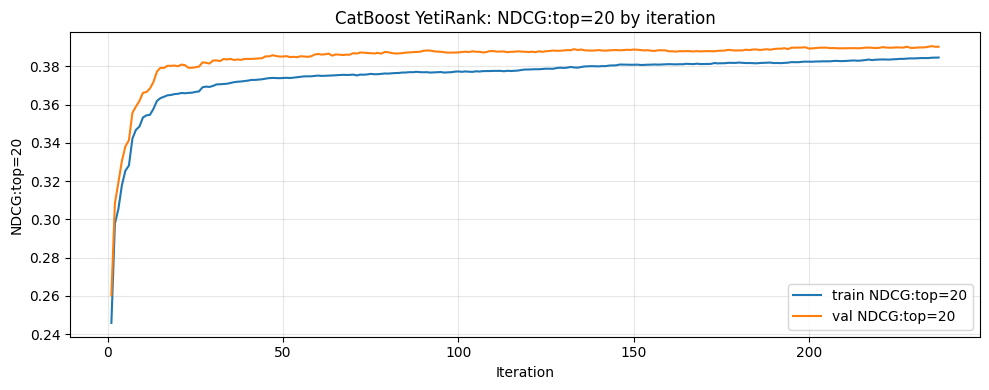

In [64]:
plot_catboost_ndcg_curve(
    yeti,
    train_pool=train_pool,
    val_pool=test_pool,
    metric_name="NDCG:top=20",
    title_prefix="CatBoost YetiRank"
)

####ApproxNDCG + Neural Net

In [67]:
neural_approx = NeuralRanker(
    input_dim=len(feat_cols),
    loss=ApproxNDCGLoss(alpha=1.0),
    hidden_dims=[256, 128, 64],
    device=DEVICE
)
train_losses_a, train_ndcgs_a, val_ndcgs_a = train_neural_ranker(
    neural_approx, train_loader, test_loader, epochs=20, lr=0.0005, verbose=True, print_every=1, k_ndcg=20
)

test_ndcg_approx, approx_query_map = evaluate_neural_model(neural_approx, test_loader, k=20)
results['ApproxNDCG (NN)'] = test_ndcg_approx
query_ndcg_dict['ApproxNDCG (NN)'] = approx_query_map
print(f"Test NDCG@20: {results['ApproxNDCG (NN)']:.4f} ({len(approx_query_map)} queries)")

Training:   0%|          | 0/96 [00:00<?, ?it/s]

Validating on train:   0%|          | 0/96 [00:00<?, ?it/s]

Validating:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/20: Loss=2.4732, Train NDCG@20=0.2800, Val NDCG@20=0.2808


Training:   0%|          | 0/96 [00:00<?, ?it/s]

...

Epoch 19/20: Loss=2.1568, Train NDCG@20=0.3656, Val NDCG@20=0.3758


Training:   0%|          | 0/96 [00:00<?, ?it/s]

Validating on train:   0%|          | 0/96 [00:00<?, ?it/s]

Validating:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 20/20: Loss=2.1585, Train NDCG@20=0.3680, Val NDCG@20=0.3775
Test NDCG@20: 0.3775 (739 queries)


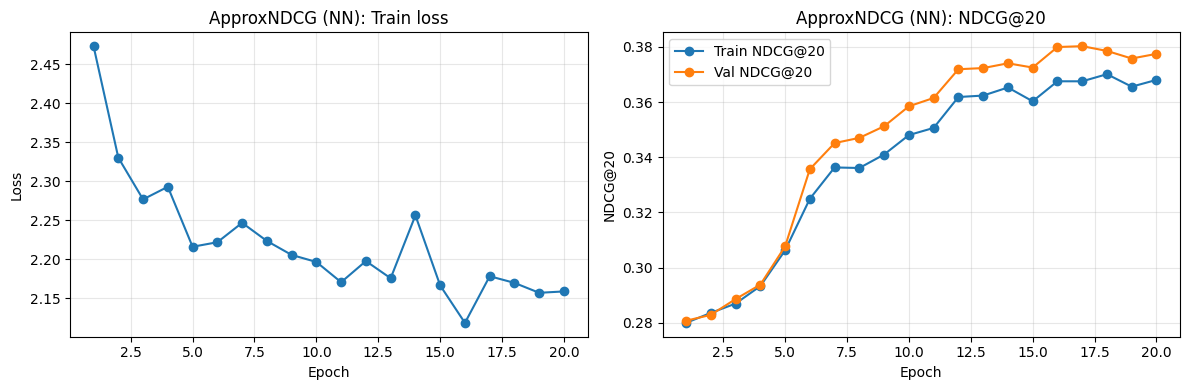

In [68]:
plot_nn_training_curves(train_losses_a, train_ndcgs_a, val_ndcgs_a, k=20, title_prefix="ApproxNDCG (NN)")

####LambdaRank + Neural Net

In [69]:
neural_lambda = NeuralRanker(
    input_dim=len(feat_cols),
    loss=LambdaRankLoss(k=20, sigma=2.0, reduction="mean"),
    hidden_dims=[256, 128, 64],
    device=DEVICE
)
train_losses, train_ndcgs_nn, val_ndcgs_nn = train_neural_ranker(
    neural_lambda, train_loader, test_loader, epochs=20, lr=0.001, verbose=True, print_every=1, k_ndcg=20
)

test_ndcg_lambda, lambda_query_map = evaluate_neural_model(neural_lambda, test_loader, k=20)
results['LambdaRank (NN)'] = test_ndcg_lambda
query_ndcg_dict['LambdaRank (NN)'] = lambda_query_map
print(f"Test NDCG@20: {results['LambdaRank (NN)']:.4f} ({len(lambda_query_map)} queries)")

Training:   0%|          | 0/96 [00:00<?, ?it/s]

Validating on train:   0%|          | 0/96 [00:00<?, ?it/s]

Validating:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/20: Loss=0.0307, Train NDCG@20=0.2849, Val NDCG@20=0.2808


Training:   0%|          | 0/96 [00:00<?, ?it/s]

...

Epoch 19/20: Loss=0.0299, Train NDCG@20=0.3562, Val NDCG@20=0.3685


Training:   0%|          | 0/96 [00:00<?, ?it/s]

Validating on train:   0%|          | 0/96 [00:00<?, ?it/s]

Validating:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 20/20: Loss=0.0298, Train NDCG@20=0.3708, Val NDCG@20=0.3831
Test NDCG@20: 0.3831 (739 queries)


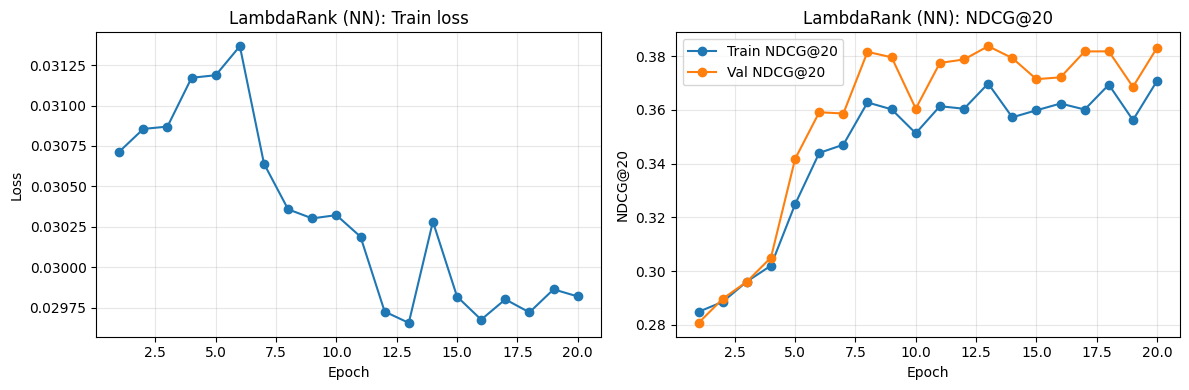

In [70]:
plot_nn_training_curves(train_losses, train_ndcgs_nn, val_ndcgs_nn, k=20, title_prefix="LambdaRank (NN)")

####LLM as Optimizer

The split into 4 sets is needed because in LLM-as-optimizer the validation is used iteratively, and if the data is not separated, it is easy to "overfit" the weights to the validation.

* train_inner — the "past" for feature preparation / calibrations: normalization parameters (z-score: means and stds) are computed here. This simulates training on historical data and prevents leakage of statistics from the future.
* val_opt — validation for search: the LLM repeatedly evaluates candidate weights against it and selects directions for improvement (black-box metric optimization).
* val_select — validation for fair selection: among all candidates found on val_opt, the final weights are chosen based on data that the LLM "did not see" during the optimization process. This reduces overfitting to val_opt.
* test — final held-out evaluation of quality, used once for reporting.


In [71]:
train_dates = sorted(train_dates)
n = len(train_dates)

n_val_select = max(1, int(n * 0.2))
n_val_opt = max(1, int(n * 0.2))

val_select_dates = train_dates[-n_val_select:]
val_opt_dates = train_dates[-(n_val_select + n_val_opt):-n_val_select]
train_inner_dates = train_dates[:-(n_val_select + n_val_opt)]

train_inner_df = interactions_with_features.filter(pl.col("date").is_in(train_inner_dates)).to_pandas()
val_opt_df = interactions_with_features.filter(pl.col("date").is_in(val_opt_dates)).to_pandas()
val_select_df = interactions_with_features.filter(pl.col("date").is_in(val_select_dates)).to_pandas()

print("train_inner:", train_inner_dates[0], train_inner_dates[-1], len(train_inner_df))
print("val_opt:", val_opt_dates[0], val_opt_dates[-1], len(val_opt_df))
print("val_select:", val_select_dates[0], val_select_dates[-1], len(val_select_df))
print("test:", test_dates[0], test_dates[-1], len(test_df))

train_inner: 2024-01-04 2024-01-19 164765
val_opt: 2024-01-20 2024-01-23 40061
val_select: 2024-01-24 2024-01-27 46867
test: 2024-01-28 2024-02-02 60365


In [72]:
feat_cols = [c for c in (TOP_FEATURES + RECENCY_FEATURES) if c in train_inner_df.columns]
print("Optimizing features:", feat_cols)

Optimizing features: ['f_user_item_target2_share_lag30', 'f_user_item_target1_share_lag30', 'f_item_target2_popularity_lag30', 'f_user_target2_share_lag30', 'f_user_target0_share_lag30', 'f_user_cluster_target2_share_lag30', 'f_user_cluster_target1_share_lag30', 'f_cluster_target2_share_lag30']


In [73]:
EPS = 1e-9

mu, sd = fit_standardizer(train_inner_df, feat_cols)
train_inner_s = apply_standardizer(train_inner_df, feat_cols, mu, sd)
val_opt_s = apply_standardizer(val_opt_df, feat_cols, mu, sd)
val_select_s = apply_standardizer(val_select_df, feat_cols, mu, sd)
test_s = apply_standardizer(test_df, feat_cols, mu, sd)

val_opt_prep = prepare(val_opt_s, feat_cols, k=20)
val_select_prep = prepare(val_select_s, feat_cols, k=20)
test_prep = prepare(test_s, feat_cols, k=20)

WEIGHT_BOUNDS = {"bias": (-3.0, 3.0)}
for c in feat_cols:
    WEIGHT_BOUNDS[c] = (-6.0, 6.0)

In [74]:
history = llm_optimize(val_opt_prep, n_trials=25)

best_w = None
best_sel = -1e9
for h in history:
    sel_score, _ = eval_weights(h["w"], val_select_prep)
    if sel_score > best_sel:
        best_sel = sel_score
        best_w = h["w"]

print("BEST weights:", best_w)

val_opt_mean, val_opt_query_ndcg, _ = eval_weights_full(best_w, val_opt_prep, feat_cols)
val_sel_mean, val_sel_query_ndcg, _ = eval_weights_full(best_w, val_select_prep, feat_cols)

print("BEST val_opt mean NDCG@20:", val_opt_mean)
print("BEST val_select mean NDCG@20:", val_sel_mean)

test_mean, test_query_ndcg, _ = eval_weights_full(best_w, test_prep, feat_cols)
print("FINAL TEST mean NDCG@20:", test_mean)

results["LLM_optimizer"] = test_mean
query_ndcg_dict["LLM_optimizer"] = test_query_ndcg

  0%|          | 0/24 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{'w': {'bias': 2.0, 'f_user_item_target2_share_lag30': -3.0, 'f_user_item_target1_share_lag30': 6.0, 'f_item_target2_popularity_lag30': 0.0, 'f_user_target2_share_lag30': 0.0, 'f_user_target0_share_lag30': 3.0, 'f_user_cluster_target2_share_lag30': -6.0, 'f_user_cluster_target1_share_lag30': 0.0, 'f_cluster_target2_share_lag30': 0.0}, 'score': 0.16563276946544647, 'raw': '{"bias":2.0,"f_user_item_target2_share_lag30":-3.0,"f_user_item_target1_share_lag30":6.0,"f_item_target2_popularity_lag30":0.0,"f_user_target2_share_lag30":0.0,"f_user_target0_share_lag30":3.0,"f_user_cluster_target2_share_lag30":-6.0,"f_user_cluster_target1_share_lag30":0.0,"f_cluster_target2_share_lag30":0.0}'}
[trial 2/25] val_opt NDCG@20=0.165633 | best=0.316426
{'w': {'bias': 0.0, 'f_user_item_target2_share_lag30': 0.0, 'f_user_item_target1_share_lag30': -1.0, 'f_item_target2_popularity_lag30': 0.0, 'f_user_target2_share_lag30': 1.0, 'f_user_target0_share_lag30': -1.0, 'f_user_cluster_target2_share_lag30': 0.0, '

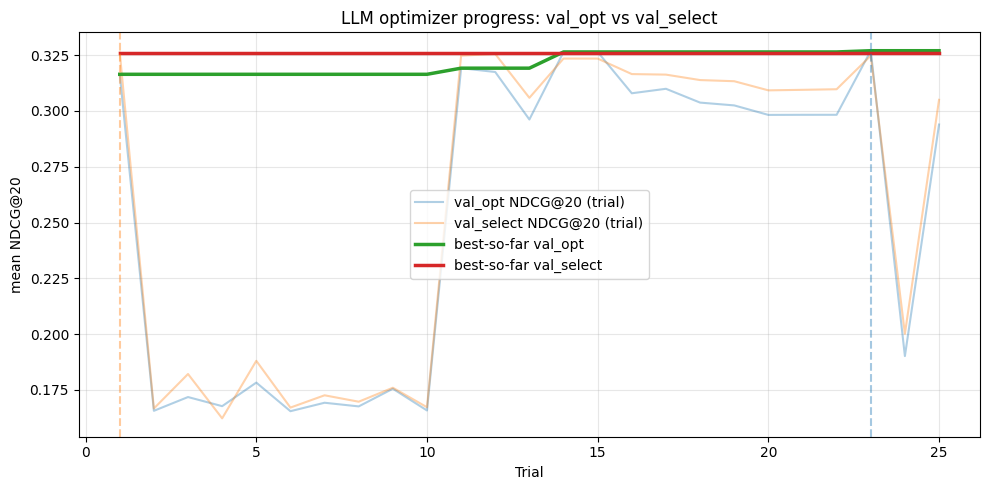

In [75]:
# LLM_Optimizer
plot_llm_optimizer_progress(history, val_select_prep, eval_weights, k=20)

In [76]:
history = llm_optimize(val_opt_prep, n_trials=25)

best_w = None
best_sel = -1e9
for h in history:
    sel_score, _ = eval_weights(h["w"], val_select_prep)
    if sel_score > best_sel:
        best_sel = sel_score
        best_w = h["w"]

print("BEST weights:", best_w)

val_opt_mean, val_opt_query_ndcg, _ = eval_weights_full(best_w, val_opt_prep, feat_cols)
val_sel_mean, val_sel_query_ndcg, _ = eval_weights_full(best_w, val_select_prep, feat_cols)

print("BEST val_opt mean NDCG@20:", val_opt_mean)
print("BEST val_select mean NDCG@20:", val_sel_mean)

test_mean, test_query_ndcg, _ = eval_weights_full(best_w, test_prep, feat_cols)
print("FINAL TEST mean NDCG@20:", test_mean)

results["LLM_optimizer_no_instr"] = test_mean
query_ndcg_dict["LLM_optimizer_no_instr"] = test_query_ndcg

  0%|          | 0/24 [00:00<?, ?it/s]

{'w': {'bias': 2.0, 'f_user_item_target2_share_lag30': -5.0, 'f_user_item_target1_share_lag30': 0.0, 'f_item_target2_popularity_lag30': 0.0, 'f_user_target2_share_lag30': 0.0, 'f_user_target0_share_lag30': 2.0, 'f_user_cluster_target2_share_lag30': 0.0, 'f_user_cluster_target1_share_lag30': 0.0, 'f_cluster_target2_share_lag30': 1.0}, 'score': 0.14990882575511932, 'raw': '{"bias":2.0,"f_user_item_target2_share_lag30":-5.0,"f_user_item_target1_share_lag30":0.0,"f_item_target2_popularity_lag30":0.0,"f_user_target2_share_lag30":0.0,"f_user_target0_share_lag30":2.0,"f_user_cluster_target2_share_lag30":0.0,"f_user_cluster_target1_share_lag30":0.0,"f_cluster_target2_share_lag30":1.0}'}
[trial 2/25] val_opt NDCG@20=0.149909 | best=0.316426
{'w': {'bias': 1.5, 'f_user_item_target2_share_lag30': -5.5, 'f_user_item_target1_share_lag30': 0.0, 'f_item_target2_popularity_lag30': 0.0, 'f_user_target2_share_lag30': 0.0, 'f_user_target0_share_lag30': 1.0, 'f_user_cluster_target2_share_lag30': 0.0, 'f_u

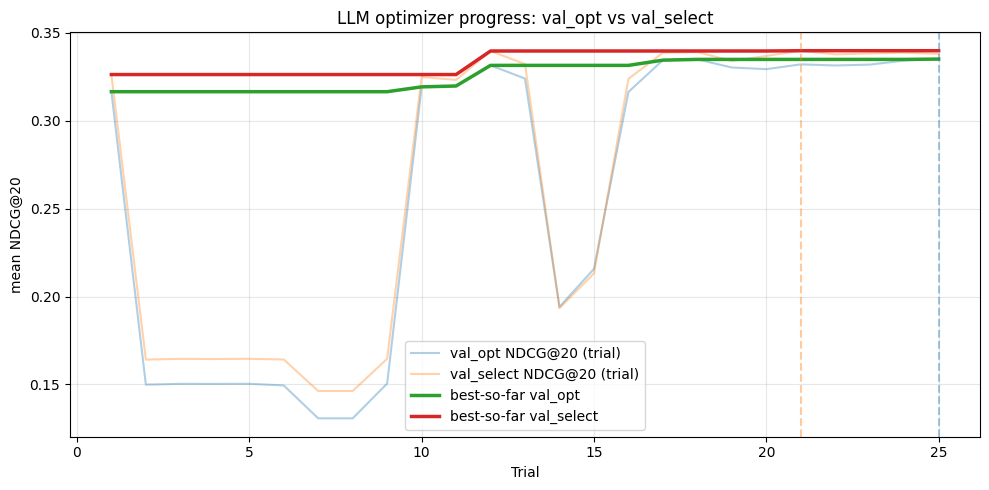

In [77]:
# LLM_Optimizer no instr
plot_llm_optimizer_progress(history, val_select_prep, eval_weights, k=20)

### Results

In [96]:
comparison_df = compute_statistical_comparison_table(query_ndcg_dict, n_bootstrap=1000, alpha=0.05)
print_comparison_table(comparison_df)


STATISTICAL COMPARISON TABLE (Paired Bootstrap - One-Tailed)
          Model A                Model B                                   Relation  Δ NDCG  CI 2.5%  CI 97.5%  p-value Sig.
           Random      CatBoost YetiRank                 CatBoost YetiRank > Random -0.2145  -0.2342   -0.1953    0.000  ***
           Random        ApproxNDCG (NN)                   ApproxNDCG (NN) > Random -0.2017  -0.2207   -0.1824    0.000  ***
           Random        LambdaRank (NN)                   LambdaRank (NN) > Random -0.2073  -0.2272   -0.1894    0.000  ***
           Random          LLM_optimizer                     LLM_optimizer > Random -0.1583  -0.1771   -0.1401    0.000  ***
           Random LLM_optimizer_no_instr            LLM_optimizer_no_instr > Random -0.1726  -0.1916   -0.1526    0.000  ***
CatBoost YetiRank        ApproxNDCG (NN)        CatBoost YetiRank > ApproxNDCG (NN)  0.0128   0.0052    0.0201    0.001   **
CatBoost YetiRank        LambdaRank (NN)        CatBoost YetiRa

In [97]:
print("\n" + "=" * 70)
print("FINAL RESULTS (Test NDCG@20)")
print("=" * 70)
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
for rank, (name, score) in enumerate(sorted_results, 1):
    print(f"{rank}. {name:<25} {score:.4f}")


FINAL RESULTS (Test NDCG@20)
1. CatBoost YetiRank         0.3903
2. LambdaRank (NN)           0.3831
3. ApproxNDCG (NN)           0.3775
4. LLM_optimizer_no_instr    0.3484
5. LLM_optimizer             0.3342
6. Random                    0.1758


#### Feature Importances

For Catboost and LLM we can directly see what features the model considers most important. So, the factors that matter most are how many times the user has bought this product, how many times the user has viewed the product (with negative weight), and overall popularity of the product. Quite a resonable setting for FMCG.

In [113]:
feat_cols = [col for col in train_df.columns if col.startswith('f_')]

imps = yeti.get_feature_importance(type="PredictionValuesChange")
pairs = sorted(zip(yeti.feature_names_, imps), key=lambda x: x[1], reverse=True)
for name, val in pairs[:10]:
    print(f"{feat_cols[int(name)]}: {val}")

f_user_item_target2_share_lag30: 43.63950310716671
f_item_target0_share_lag30: 14.222545051840694
f_item_target2_share_lag30: 8.361734920365754
f_item_target2_popularity_lag30: 5.726982067388122
f_cluster_target0_share_lag30: 5.361788995562102
f_user_item_target1_share_lag30: 5.226593198990062
f_user_item_target0_share_lag30: 5.110889622946259
f_item_target0_popularity_lag30: 1.7009264196511749
f_user_cluster_target2_share_lag30: 1.6772369734804062
f_cluster_target1_share_lag30: 1.4838421885233808


In [112]:
best_w

{'bias': 0.25,
 'f_user_item_target2_share_lag30': 0.55,
 'f_user_item_target1_share_lag30': -0.25,
 'f_item_target2_popularity_lag30': 0.15,
 'f_user_target2_share_lag30': 0.65,
 'f_user_target0_share_lag30': -0.25,
 'f_user_cluster_target2_share_lag30': 0.55,
 'f_user_cluster_target1_share_lag30': 0.05,
 'f_cluster_target2_share_lag30': 0.3}

# Conclusions

In this project, we formulated a real-world recommendation ranking problem as an optimization task and compared several modern methods for maximizing the non-differentiable NDCG@20 metric.

All implemented methods — CatBoost with YetiRank, neural networks with ApproxNDCG and LambdaRank losses, and a novel LLM-as-Optimizer — significantly outperformed the random baseline. CatBoost YetiRank (highly optimized out-of-the-box method) achieved the highest test performance. The two neural surrogates showed comparable performance. The LLM-based optimizer performed slightly worse, yet it still proved itself to be a viable gradient‑free alternative.

Our core conclusion is that replacing the true non-differentiable NDCG objective with a differentiable approximation or an implicit gradient definition is a powerful strategy for learning to rank task.